In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: set seaborn style for better visuals
sns.set(style="whitegrid")


In [13]:
df = pd.read_excel("oba_conda11.xlsx", engine="openpyxl")


In [14]:
df.head(5)


,EID,early?,GROUP,YEAR,FAC,SEX,RACE,AGE,TYPE,BMI,ASA,DUR,HW,PCA_CONT,DSCPOR,POD-0,POD-1,POD-2,POD-3
0,15841832,No,CEA,2,SPOKANE,Female,White,14.056298,5-Epi (w/Opioid),26.955681,1,209,43.0,NaN,127.416667,0.025704,0.008307,0.026328,0.038793
1,16212574,No,OBA,1,LEXINGTON,Male,White,16.207123,2-Morphine-PCA,21.428397,2,341,23.0,No,125.933333,0.098636,0.134205,0.066288,0.047348
2,16256322,No,OBA,1,LEXINGTON,Female,White,17.511214,3-Hydromorphone-PCA,35.325744,2,384,15.0,No,192.600000,0.100137,0.114439,0.065214,0.083277
3,16318565,No,OBA,1,PORTLAND,Female,White,18.992814,3-Hydromorphone-PCA,24.349609,2,267,18.0,Both,150.700000,0.274671,0.194561,0.098787,0.042032
4,16332561,No,OBA,1,LEXINGTON,Female,White,18.374256,2-Morphine-PCA,23.060797,1,249,15.0,No,124.100000,0.097770,0.153581,0.118203,0.064322


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2573 entries, 0 to 2572
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EID       2573 non-null   int64  
 1   early?    2573 non-null   object 
 2   GROUP     2573 non-null   object 
 3   YEAR      2573 non-null   int64  
 4   FAC       2573 non-null   object 
 5   SEX       2573 non-null   object 
 6   RACE      2573 non-null   object 
 7   AGE       2573 non-null   float64
 8   TYPE      2573 non-null   object 
 9   BMI       2573 non-null   float64
 10  ASA       2573 non-null   int64  
 11  DUR       2573 non-null   int64  
 12  HW        2573 non-null   float64
 13  PCA_CONT  2045 non-null   object 
 14  DSCPOR    2381 non-null   float64
 15  POD-0     2573 non-null   float64
 16  POD-1     2573 non-null   float64
 17  POD-2     2565 non-null   float64
 18  POD-3     2491 non-null   float64
dtypes: float64(8), int64(4), object(7)
memory usage: 382.1+ KB


In [16]:
type_relabel = {
    "2-Morphine-PCA": "1-Morphine-PCA",
    "3-Hydromorphone-PCA": "2-Hydromorphone-PCA",
    "5-Epi (w/Opioid)": "3-Epi (w/Opioid)",
    "6-Block w/Opioid": "4-Block w/Opioid"
}
types_to_drop = ["1-IV Opioids", "4-Epi (No Opioid)"]
fac_to_drop = ['SALT LAKE CITY']

In [17]:
df = df.copy()
df = df[~df["TYPE"].isin(types_to_drop)] 
df = df[~df["FAC"].isin(fac_to_drop)]# Drop unwanted types
df["TYPE"] = df["TYPE"].replace(type_relabel)  # Relabel remaining types
df["GROUP"] = df["GROUP"].replace({"OBA": "1-PCA"})  # Rename GROUP

In [18]:
df["GROUP"] = df["GROUP"].replace({"CEA": "2-Epidural"})  # Rename GROUP
df["GROUP"] = df["GROUP"].replace({"SPINAL": "3-Spinal"})  # Rename GROUP

In [19]:
df['TYPE'].value_counts()

TYPE
1-Morphine-PCA         1160
2-Hydromorphone-PCA     858
3-Epi (w/Opioid)        263
4-Block w/Opioid         90
Name: count, dtype: int64

In [20]:
df['GROUP'].value_counts()

GROUP
1-PCA         2018
2-Epidural     263
3-Spinal        90
Name: count, dtype: int64

In [21]:
df['FAC'].value_counts()

FAC
PHILADELPHIA       323
SHREVEPORT         300
SPOKANE            263
GREENVILLE         255
CHICAGO            243
ST. LOUIS          224
PORTLAND           214
TAMPA              147
SPRINGFIELD        121
HOUSTON             87
LEXINGTON           80
NORTHERN CALIFO     66
HONOLULU            48
Name: count, dtype: int64

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2371 entries, 0 to 2572
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EID       2371 non-null   int64  
 1   early?    2371 non-null   object 
 2   GROUP     2371 non-null   object 
 3   YEAR      2371 non-null   int64  
 4   FAC       2371 non-null   object 
 5   SEX       2371 non-null   object 
 6   RACE      2371 non-null   object 
 7   AGE       2371 non-null   float64
 8   TYPE      2371 non-null   object 
 9   BMI       2371 non-null   float64
 10  ASA       2371 non-null   int64  
 11  DUR       2371 non-null   int64  
 12  HW        2371 non-null   float64
 13  PCA_CONT  2035 non-null   object 
 14  DSCPOR    2371 non-null   float64
 15  POD-0     2371 non-null   float64
 16  POD-1     2371 non-null   float64
 17  POD-2     2365 non-null   float64
 18  POD-3     2305 non-null   float64
dtypes: float64(8), int64(4), object(7)
memory usage: 370.5+ KB


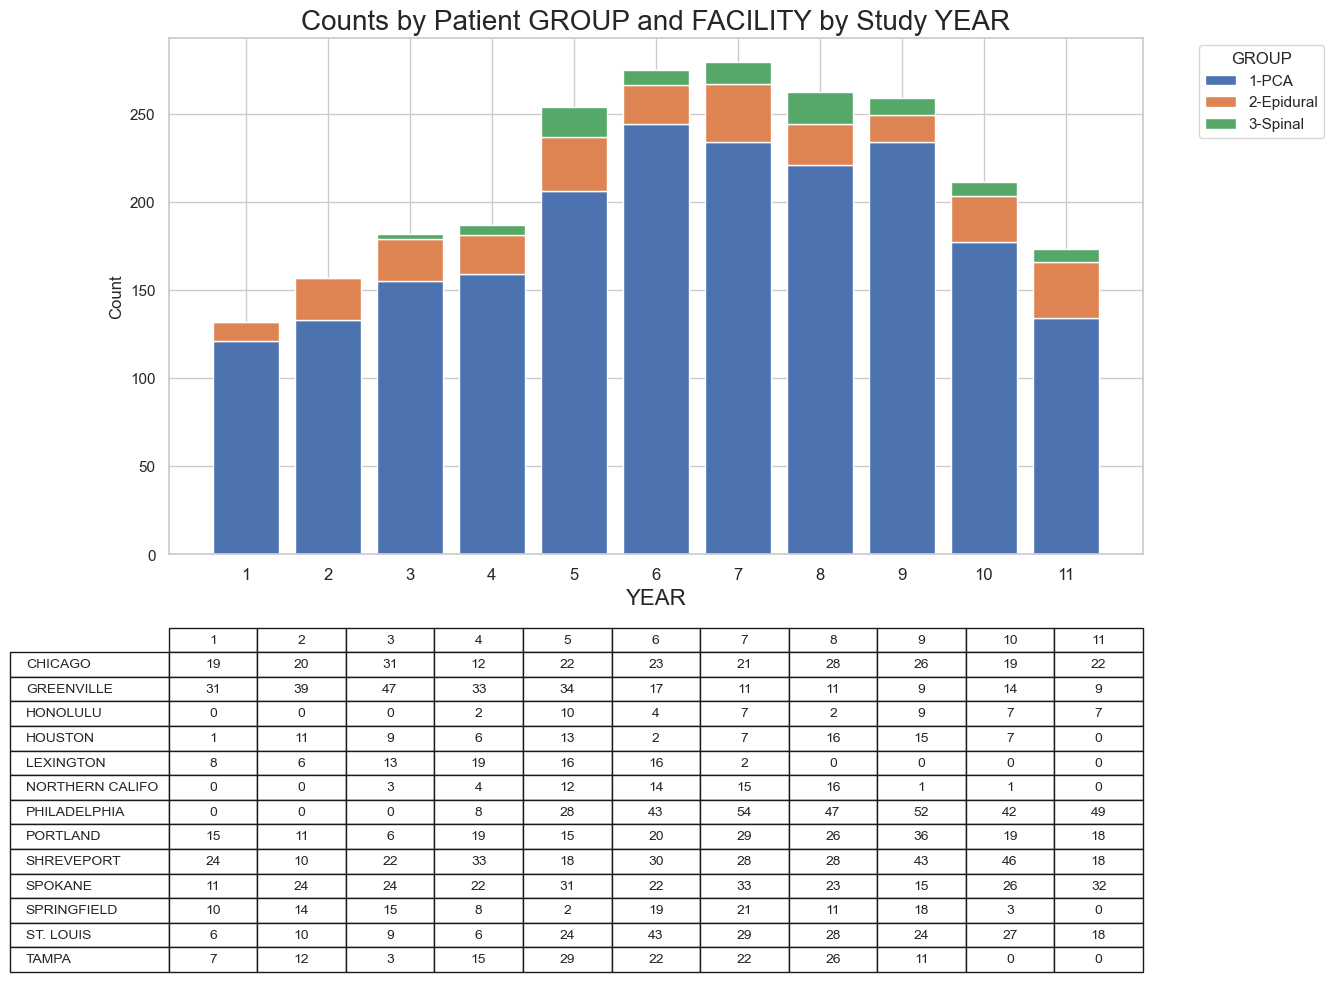

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure YEAR is categorical and sorted from 1 to 11
df["YEAR"] = pd.Categorical(df["YEAR"].astype(str), categories=[str(i) for i in range(1, 12)], ordered=True)

# Sort TYPE based on leading digit in reverse order
type_order = sorted(df["GROUP"].unique(), key=lambda x: int(x.split("-")[0]))

# Create stacked bar data
stacked_data = df.groupby(["YEAR", "GROUP"]).size().unstack(fill_value=0)
stacked_data = stacked_data[type_order]  # Apply sorted TYPE order

# Crosstab of FAC by YEAR
crosstab = pd.crosstab(df["FAC"], df["YEAR"])

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

# Top subplot: stacked bar
bottom = None
for i, type_name in enumerate(type_order):
    if i == 0:
        ax1.bar(stacked_data.index, stacked_data[type_name], label=type_name)
        bottom = stacked_data[type_name]
    else:
        ax1.bar(stacked_data.index, stacked_data[type_name], bottom=bottom, label=type_name)
        bottom += stacked_data[type_name]
        
        
box = ax1.get_position()
ax1.set_position([box.x0 - .2, box.y0, box.width + .2, box.height])
ax1.set_ylabel("Count")
ax1.set_xlabel("YEAR", fontsize = 16)  # ✅ Add x-axis label
ax1.tick_params(axis='x', labelsize=12)  # You can adjust 12 to any size you prefer

ax1.set_title("Counts by Patient GROUP and FACILITY by Study YEAR", fontsize = 20)
ax1.legend(title="GROUP", bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True)

# Bottom subplot: Crosstab table
ax2.axis("off")
table = ax2.table(cellText=crosstab.values,
                  rowLabels=crosstab.index,
                  colLabels=crosstab.columns,
                  loc='center',
                  cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.5)
# ✅ Add x-axis label below the table
ax2.set_xlabel("YEAR", labelpad=20)

plt.tight_layout()
plt.show()


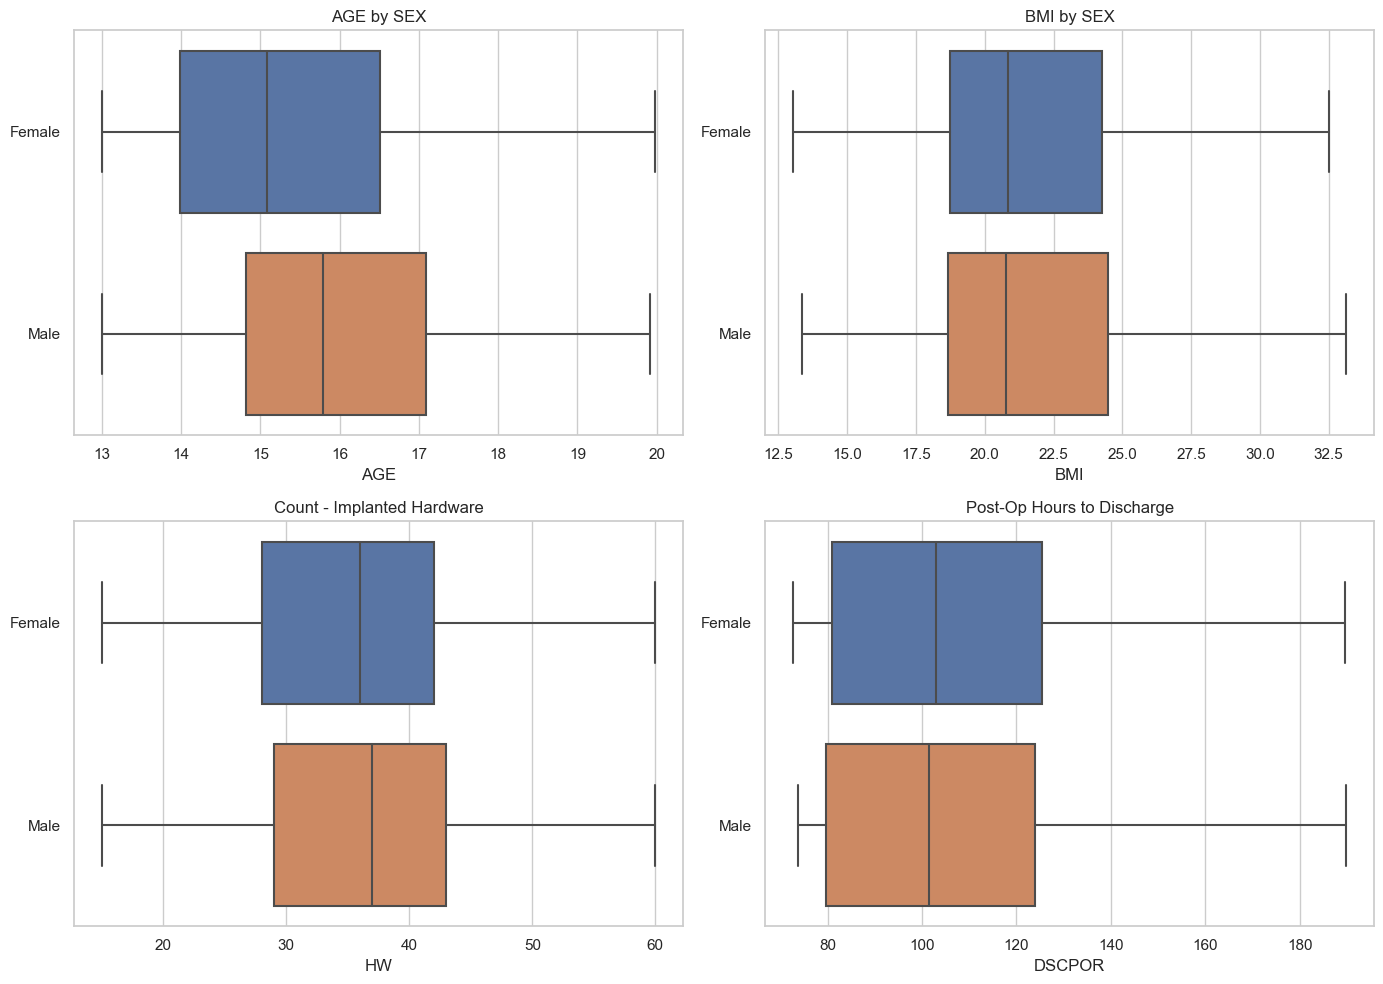

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Create DSCPOR if not already present
if "DSCPOR" not in df.columns:
    df["DSCPOR"] = df["POD-0"] + df["POD-1"] + df["POD-2"].fillna(0) + df["POD-3"].fillna(0)

# Variables and custom titles
box_vars = ["AGE", "BMI", "HW", "DSCPOR"]
titles = {
    "AGE": "AGE by SEX",
    "BMI": "BMI by SEX",
    "HW": "Count - Implanted Hardware",
    "DSCPOR": "Post-Op Hours to Discharge"
}

# Set up the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Plot each variable
for i, var in enumerate(box_vars):
    row, col = divmod(i, 2)
    ax = axes[row][col]
    sns.boxplot(data=df, x=var, y="SEX", ax=ax, orient="h", showfliers=False)
    ax.set_title(titles[var])
    ax.set_xlabel(var)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


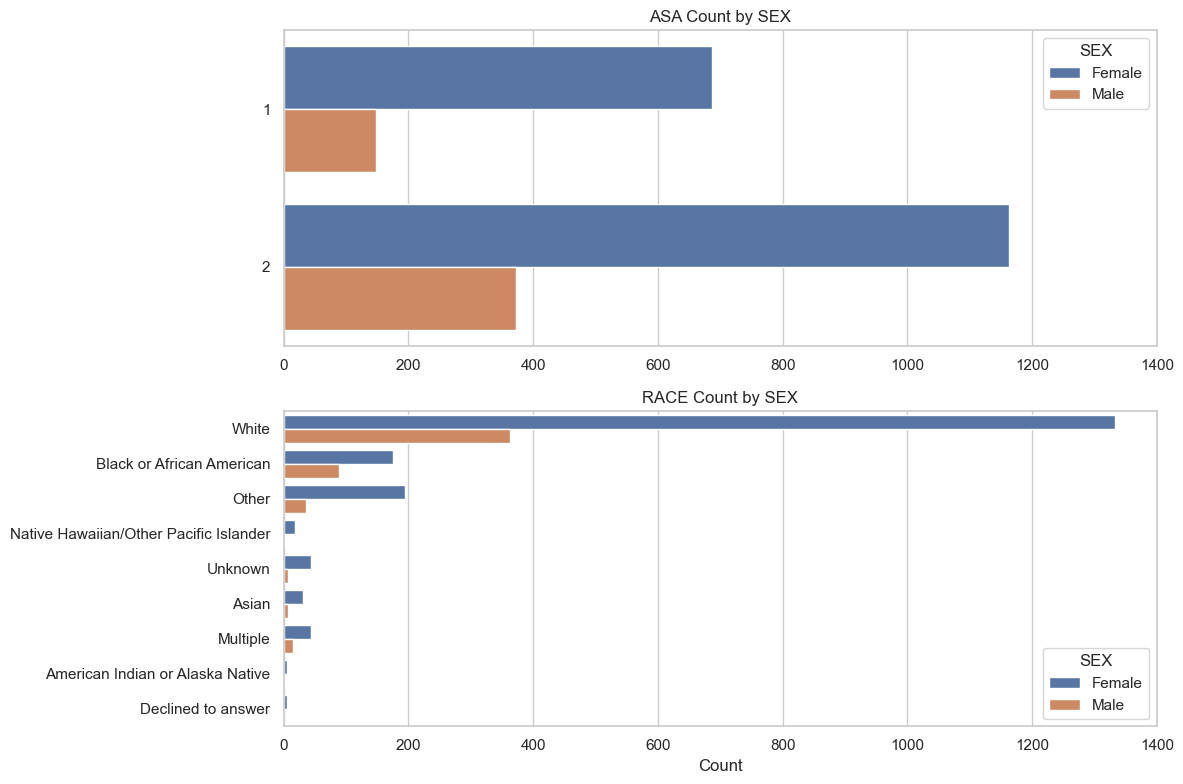

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.subplots_adjust(hspace=0.4)

# Top subplot: ASA
sns.countplot(data=df, y="ASA", hue="SEX", ax=ax1)
ax1.set_title("ASA Count by SEX")
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.set_xlim(0, 1400)
ax1.legend(title="SEX")

# Bottom subplot: RACE
sns.countplot(data=df, y="RACE", hue="SEX", ax=ax2)
ax2.set_title("RACE Count by SEX")
ax2.set_xlabel("Count")
ax2.set_ylabel("")
ax2.set_xlim(0, 1400)
ax2.legend(title="SEX")

plt.tight_layout()
plt.show()


In [13]:
# Step 1: Drop 'EID'
df = df.drop(columns='EID')

# Step 2: Rename 'early?' to 'DSC<80'
df = df.rename(columns={'early?': 'DSC<80'})

# Step 3: Melt POD columns into long format
df_melted = df.melt(
    id_vars=['DSC<80', 'GROUP', 'YEAR', 'FAC', 'SEX', 'RACE', 'AGE', 'TYPE', 'PCA_CONT','BMI','ASA','DUR','HW'],
    value_vars=['POD-0', 'POD-1', 'POD-2', 'POD-3'],
    var_name='POD',
    value_name='OME/KG/HR'
)

# Step 4: Drop rows with NaN in 'OME/KG/HR'
df_melted = df_melted.dropna(subset=['OME/KG/HR'])


In [14]:
df_melted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9412 entries, 0 to 9483
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   DSC<80     9412 non-null   object  
 1   GROUP      9412 non-null   object  
 2   YEAR       9412 non-null   category
 3   FAC        9412 non-null   object  
 4   SEX        9412 non-null   object  
 5   RACE       9412 non-null   object  
 6   AGE        9412 non-null   float64 
 7   TYPE       9412 non-null   object  
 8   PCA_CONT   8069 non-null   object  
 9   BMI        9412 non-null   float64 
 10  ASA        9412 non-null   int64   
 11  DUR        9412 non-null   int64   
 12  HW         9412 non-null   float64 
 13  POD        9412 non-null   object  
 14  OME/KG/HR  9412 non-null   float64 
dtypes: category(1), float64(4), int64(2), object(8)
memory usage: 1.1+ MB


In [15]:
df_melted['PCA_CONT'] = df_melted['PCA_CONT'].fillna('N/A')
melted_df = df_melted


In [16]:
# Convert all object columns to category
obj_cols = melted_df.select_dtypes(include='object').columns
melted_df[obj_cols] = melted_df[obj_cols].astype('category')

# Convert YEAR to category as well
#melted_df['YEAR'] = melted_df['YEAR'].astype('category')


In [17]:
melted_df['ASA'] = melted_df['ASA'].astype('category')

melted_df.info()

In [18]:
# Instead of this:
# melted_df['YEAR'] = melted_df['YEAR'].astype('category')

# Use this:
melted_df['YEAR'] = melted_df['YEAR'].astype(int)
melted_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9412 entries, 0 to 9483
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   DSC<80     9412 non-null   category
 1   GROUP      9412 non-null   category
 2   YEAR       9412 non-null   int32   
 3   FAC        9412 non-null   category
 4   SEX        9412 non-null   category
 5   RACE       9412 non-null   category
 6   AGE        9412 non-null   float64 
 7   TYPE       9412 non-null   category
 8   PCA_CONT   9412 non-null   category
 9   BMI        9412 non-null   float64 
 10  ASA        9412 non-null   category
 11  DUR        9412 non-null   int64   
 12  HW         9412 non-null   float64 
 13  POD        9412 non-null   category
 14  OME/KG/HR  9412 non-null   float64 
dtypes: category(9), float64(4), int32(1), int64(1)
memory usage: 562.8 KB


In [19]:
melted_df['TYPE'].value_counts()

TYPE
1-Morphine-PCA         4591
2-Hydromorphone-PCA    3410
3-Epi (w/Opioid)       1052
4-Block w/Opioid        359
Name: count, dtype: int64

In [20]:
import pandas as pd
from scipy.stats import mannwhitneyu

# Filter to PCA types only
subset = melted_df[melted_df["TYPE"].isin(["1-Morphine-PCA", "2-Hydromorphone-PCA"])]

# Initialize results list
results = []

# Loop through each POD level
for pod in ["POD-0", "POD-1", "POD-2", "POD-3"]:
    pod_df = subset[subset["POD"] == pod]
    group1 = pod_df[pod_df["TYPE"] == "1-Morphine-PCA"]["OME/KG/HR"]
    group2 = pod_df[pod_df["TYPE"] == "2-Hydromorphone-PCA"]["OME/KG/HR"]
    
    # Perform Mann–Whitney U test
    stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
    
    # Calculate percentage difference
    morph_median = group1.median()
    hydro_median = group2.median()
    pct_diff = ((hydro_median - morph_median) / morph_median) * 100 if morph_median != 0 else None
    
    # Add interpretation
    if p < 0.001:
        interp = "Significant difference"
    elif p < 0.05:
        interp = "Marginal difference"
    else:
        interp = "No significant difference"
    
    # Append results
    results.append({
        "POD": pod,
        "Median Morphine": round(morph_median, 4),
        "Median Hydromorphone": round(hydro_median, 4),
        "U-statistic": round(stat, 1),
        "p-value": round(p, 4),
        "% Difference (vs Morphine)": round(pct_diff, 4),
        "Interpretation": interp
    })

# Convert to DataFrame
summary_df = pd.DataFrame(results)

# Display as styled table
styled = summary_df.style.set_caption("Mann–Whitney U-Test Comparison of PCA Types by Post Op Day") \
    .format({"p-value": "{:.4f}", "% Difference (vs Morphine)": "{:+.2f}%"}) \
    .highlight_min(subset=["p-value"], color="lightgreen") \
    .set_table_styles([{"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold")]}])

styled


,POD,Median Morphine,Median Hydromorphone,U-statistic,p-value,% Difference (vs Morphine),Interpretation
0,POD-0,0.069700,0.063900,552828.500000,0.0000,-8.30%,Significant difference
1,POD-1,0.062500,0.061900,524704.000000,0.0365,-0.95%,Marginal difference
2,POD-2,0.043400,0.045000,495602.500000,0.9576,+3.68%,No significant difference
3,POD-3,0.037100,0.037200,465899.500000,0.9260,+0.09%,No significant difference


In [21]:
import pandas as pd
from scipy.stats import ks_2samp

# Filter to PCA types only
subset = melted_df[melted_df["TYPE"].isin(["1-Morphine-PCA", "2-Hydromorphone-PCA"])]

# Initialize results list
results = []

# Loop through each POD level
for pod in ["POD-0", "POD-1", "POD-2", "POD-3"]:
    pod_df = subset[subset["POD"] == pod]
    group1 = pod_df[pod_df["TYPE"] == "1-Morphine-PCA"]["OME/KG/HR"]
    group2 = pod_df[pod_df["TYPE"] == "2-Hydromorphone-PCA"]["OME/KG/HR"]
    
    # Perform Kolmogorov–Smirnov test
    stat, p = ks_2samp(group1, group2)
    
    # Calculate percentage difference in medians
    morph_median = group1.median()
    hydro_median = group2.median()
    pct_diff = ((hydro_median - morph_median) / morph_median) * 100 if morph_median != 0 else None
    
    # Add interpretation
    if p < 0.001:
        interp = "Significant distributional difference"
    elif p < 0.05:
        interp = "Marginal distributional difference"
    else:
        interp = "No significant difference"
    
    # Append results
    results.append({
        "POD": pod,
        "Median Morphine": round(morph_median, 4),
        "Median Hydromorphone": round(hydro_median, 4),
        "K–S statistic": round(stat, 4),
        "p-value": round(p, 4),
        "% Difference (vs Morphine)": round(pct_diff, 4),
        "Interpretation": interp
    })

# Convert to DataFrame
ks_df = pd.DataFrame(results)

# Display as styled table
ks_df.style.set_caption("Kolmogorov–Smirnov Comparison of PCA Types by Post Op Day") \
    .format({"p-value": "{:.4f}", "% Difference (vs Morphine)": "{:+.2f}%"}) \
    .highlight_min(subset=["p-value"], color="lightgreen") \
    .set_table_styles([{"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold")]}])


,POD,Median Morphine,Median Hydromorphone,K–S statistic,p-value,% Difference (vs Morphine),Interpretation
0,POD-0,0.069700,0.063900,0.118200,0.0000,-8.30%,Significant distributional difference
1,POD-1,0.062500,0.061900,0.093000,0.0004,-0.95%,Significant distributional difference
2,POD-2,0.043400,0.045000,0.082400,0.0023,+3.68%,Marginal distributional difference
3,POD-3,0.037100,0.037200,0.086000,0.0016,+0.09%,Marginal distributional difference


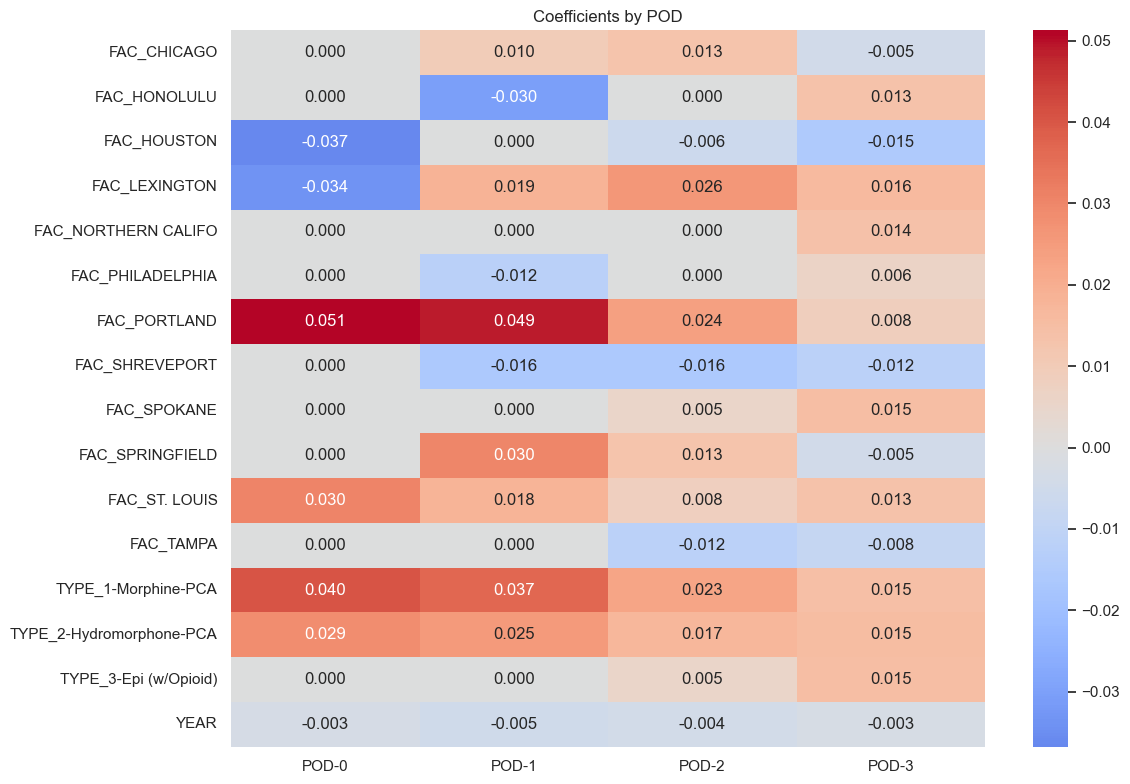

In [22]:
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Collect coefficients from filtered models
coef_matrix = {}

for pod_label in ['POD-0', 'POD-1', 'POD-2', 'POD-3']:
    pod_df = melted_df[melted_df['POD'] == pod_label].copy()
    pod_df = pod_df.dropna(subset=['OME/KG/HR'])

    # Drop RACE and ASA always; drop DSC<80 for POD-0 to POD-2
    drop_cols = ['OME/KG/HR', 'POD', 'RACE', 'ASA','SEX','DUR','PCA_CONT','AGE','BMI','GROUP','HW','DSC<80']


    X = pod_df.drop(columns=[col for col in drop_cols if col in pod_df.columns])
    y = pod_df['OME/KG/HR']

    # One-hot encode and align
    X_encoded = pd.get_dummies(X, drop_first=False).astype('float64')
    y = y.astype('float64')
    X_encoded, y = X_encoded.align(y, join='inner', axis=0)
    X_encoded = sm.add_constant(X_encoded)

    # First-pass model
    model = sm.OLS(y, X_encoded).fit()

    # Filter by p-value
    significant_vars = model.pvalues[model.pvalues < 0.05].index
    if 'const' not in significant_vars:
        significant_vars = significant_vars.insert(0, 'const')

    # Store coefficients
    coef_matrix[pod_label] = model.params[significant_vars]

# Step 2: Combine into a DataFrame
coef_df = pd.DataFrame(coef_matrix).fillna(0)
# Remove 'const' row if present
if 'const' in coef_df.index:
    coef_df = coef_df.drop(index='const')


# Step 3: Plot heatmap
plt.figure(figsize=(12, len(coef_df) * 0.5))
sns.heatmap(coef_df, annot=True, cmap='coolwarm', center=0, fmt=".3f")
plt.title("Coefficients by POD")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


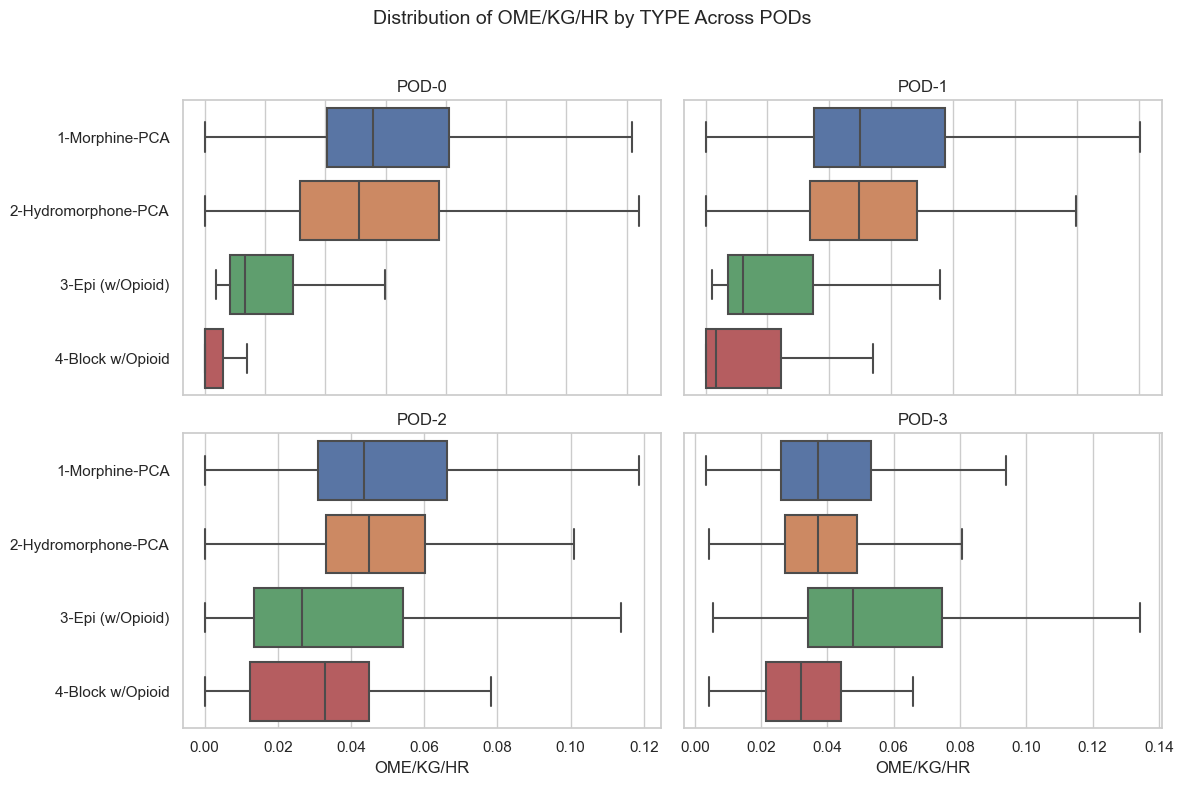

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Setup
pods = ['POD-0', 'POD-1', 'POD-2', 'POD-3']
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

# Plot each POD
for i, pod in enumerate(pods):
    ax = axes[i]
    pod_df = melted_df[melted_df['POD'] == pod]

    sns.boxplot(data=pod_df, y='TYPE', x='OME/KG/HR', ax=ax, orient='h', showfliers=False)
    ax.set_title(pod)

    # Y-axis labels only on left column
    if i in [0, 2]:
        ax.set_ylabel('')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    else:
        ax.set_ylabel('')
        ax.tick_params(axis='y', left=False, labelleft=False)

    # X-axis labels only on bottom row
    if i in [2, 3]:
        ax.set_xlabel('OME/KG/HR')
    else:
        ax.set_xlabel('')
        ax.tick_params(axis='x', bottom=False, labelbottom=False)

# Final layout
plt.suptitle("Distribution of OME/KG/HR by TYPE Across PODs", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


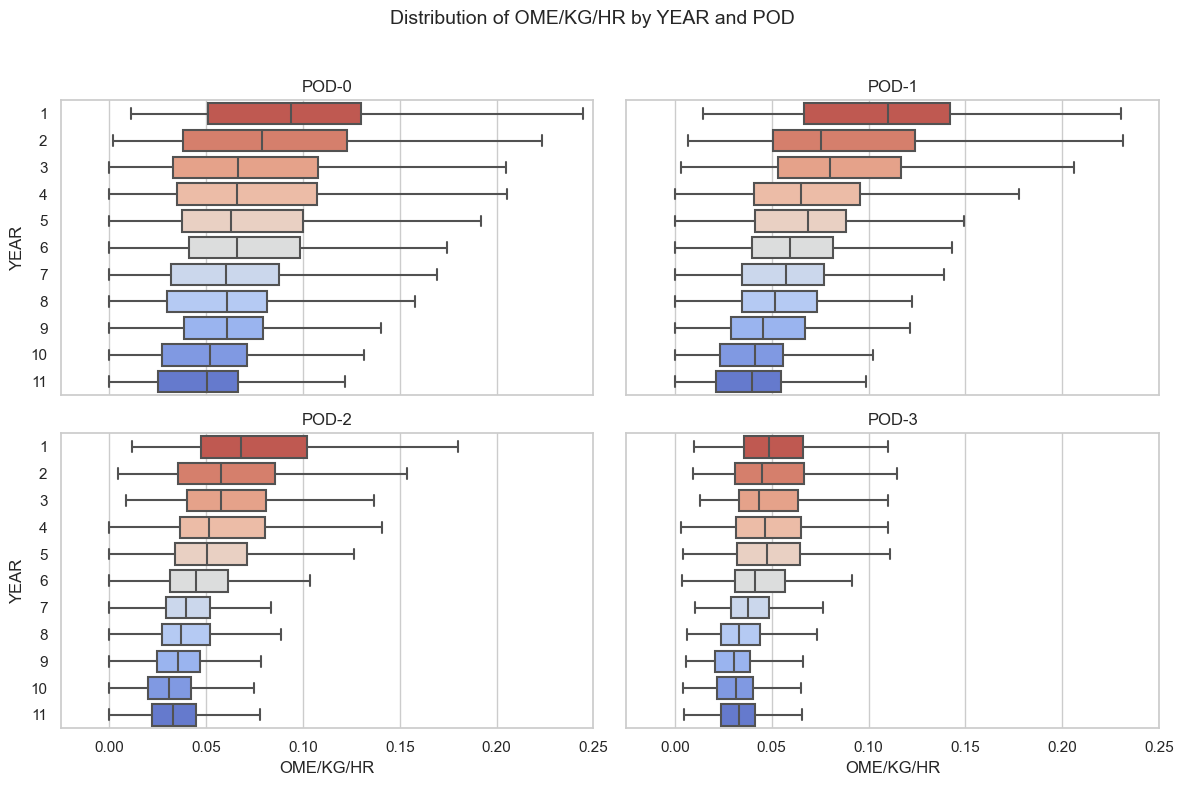

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Setup
pods = ['POD-0', 'POD-1', 'POD-2', 'POD-3']
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

# Compute global x-axis limits
x_min = melted_df['OME/KG/HR'].min()
x_max = melted_df['OME/KG/HR'].max()

# Plot each POD
for i, pod in enumerate(pods):
    ax = axes[i]
    pod_df = melted_df[melted_df['POD'] == pod]

    sns.boxplot(data=pod_df, y='YEAR', x='OME/KG/HR', ax=ax, orient='h',
                palette='coolwarm_r', showfliers=False)
    ax.set_title(pod)
    ax.set_xlim(-0.025, 0.25)

    # Y-axis labels only on left column
    if i in [0, 2]:
        ax.set_ylabel('YEAR')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    else:
        ax.set_ylabel('')
        ax.tick_params(axis='y', left=False, labelleft=False)

    # X-axis labels only on bottom row
    if i in [2, 3]:
        ax.set_xlabel('OME/KG/HR')
    else:
        ax.set_xlabel('')
        ax.tick_params(axis='x', bottom=False, labelbottom=False)

# Final layout
plt.suptitle("Distribution of OME/KG/HR by YEAR and POD", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [25]:
melted_df['FAC'].value_counts()

FAC
PHILADELPHIA       1288
SHREVEPORT         1169
SPOKANE            1052
GREENVILLE         1001
CHICAGO             972
ST. LOUIS           895
PORTLAND            846
TAMPA               586
SPRINGFIELD         484
HOUSTON             345
LEXINGTON           319
NORTHERN CALIFO     263
HONOLULU            192
Name: count, dtype: int64

In [26]:
# Grouped value_counts for FAC by POD
print("FAC counts by POD:\n")
for pod in melted_df['POD'].unique():
    print(f"\n{pod}:\n")
    print(melted_df[melted_df['POD'] == pod]['FAC'].value_counts())

# Grouped value_counts for TYPE by POD
print("\nTYPE counts by POD:\n")
for pod in melted_df['POD'].unique():
    print(f"\n{pod}:\n")
    print(melted_df[melted_df['POD'] == pod]['TYPE'].value_counts())


FAC counts by POD:


POD-0:

FAC
PHILADELPHIA       323
SHREVEPORT         300
SPOKANE            263
GREENVILLE         255
CHICAGO            243
ST. LOUIS          224
PORTLAND           214
TAMPA              147
SPRINGFIELD        121
HOUSTON             87
LEXINGTON           80
NORTHERN CALIFO     66
HONOLULU            48
Name: count, dtype: int64

POD-1:

FAC
PHILADELPHIA       323
SHREVEPORT         300
SPOKANE            263
GREENVILLE         255
CHICAGO            243
ST. LOUIS          224
PORTLAND           214
TAMPA              147
SPRINGFIELD        121
HOUSTON             87
LEXINGTON           80
NORTHERN CALIFO     66
HONOLULU            48
Name: count, dtype: int64

POD-2:

FAC
PHILADELPHIA       322
SHREVEPORT         299
SPOKANE            263
GREENVILLE         254
CHICAGO            243
ST. LOUIS          224
PORTLAND           212
TAMPA              147
SPRINGFIELD        121
HOUSTON             86
LEXINGTON           80
NORTHERN CALIFO     66
HONOLULU       

In [27]:
import pandas as pd
from scipy.stats import mannwhitneyu, ks_2samp
import numpy as np

# Function to calculate Cliff's Delta
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    total = nx * ny
    greater = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    return (greater - less) / total

# Setup
types_to_compare = ["2-Hydromorphone-PCA", "3-Epi (w/Opioid)", "4-Block w/Opioid"]
pods = ["POD-0", "POD-1", "POD-2", "POD-3"]
results = []

for pod in pods:
    pod_df = melted_df[melted_df["POD"] == pod]
    morph = pod_df[pod_df["TYPE"] == "1-Morphine-PCA"]["OME/KG/HR"].dropna()

    for comp_type in types_to_compare:
        comp = pod_df[pod_df["TYPE"] == comp_type]["OME/KG/HR"].dropna()
        if len(morph) == 0 or len(comp) == 0:
            continue

        # Mann–Whitney U
        u_stat, u_p = mannwhitneyu(morph, comp, alternative='two-sided')

        # Kolmogorov–Smirnov
        ks_stat, ks_p = ks_2samp(morph, comp)

        # Cliff's Delta
        delta = cliffs_delta(morph, comp)

        # Median difference
        morph_median = morph.median()
        comp_median = comp.median()
        pct_diff = ((comp_median - morph_median) / morph_median) * 100 if morph_median != 0 else None

        # Clinical interpretation
        if pct_diff is not None and abs(pct_diff) >= 20:
            clinical = "Clinically significant"
        elif pct_diff is not None and abs(pct_diff) >= 10:
            clinical = "Possibly significant"
        else:
            clinical = "Not clinically significant"

        results.append({
            "POD": pod,
            "Compared TYPE": comp_type,
            "Mann–Whitney p": round(u_p, 4),
            "K–S p": round(ks_p, 4),
            "Cliff's Delta": round(delta, 3),
            "Median Morphine": round(morph_median, 4),
            "Median Compared": round(comp_median, 4),
            "% Difference": round(pct_diff, 2),
            "Clinical Interpretation": clinical
        })

# Create summary table
summary_df = pd.DataFrame(results)

# Display
summary_df.style.set_caption(
    "<strong>Statistical and Clinical Comparison vs Morphine-PCA</strong><br>"
    "<br>"
    "• Mann–Whitney U test (median difference)<br>"
    "• Kolmogorov–Smirnov test (distributional difference)<br>"
    "• Cliff’s Delta (effect size)<br>"
    "<br>"
    "• ≥ 20% reduction → Clinically significant<br>"
    "• 10–19.99% reduction → Possibly significant<br>"
    "• < 10% reduction or increase → Not clinically significant"
)\
    .format({"Mann–Whitney p": "{:.4f}", "K–S p": "{:.4f}", "% Difference": "{:+.2f}%"}) \
    .highlight_min(subset=["Mann–Whitney p", "K–S p"], color="lightgreen") \
    .set_table_styles([{"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold")]}])


,POD,Compared TYPE,Mann–Whitney p,K–S p,Cliff's Delta,Median Morphine,Median Compared,% Difference,Clinical Interpretation
0,POD-0,2-Hydromorphone-PCA,0.0000,0.0000,0.111000,0.069700,0.063900,-8.30%,Not clinically significant
1,POD-0,3-Epi (w/Opioid),0.0000,0.0000,0.709000,0.069700,0.016800,-75.83%,Clinically significant
2,POD-0,4-Block w/Opioid,0.0000,0.0000,0.861000,0.069700,0.000000,-100.00%,Clinically significant
3,POD-1,2-Hydromorphone-PCA,0.0365,0.0004,0.054000,0.062500,0.061900,-0.95%,Not clinically significant
4,POD-1,3-Epi (w/Opioid),0.0000,0.0000,0.678000,0.062500,0.015100,-75.86%,Clinically significant
5,POD-1,4-Block w/Opioid,0.0000,0.0000,0.800000,0.062500,0.004100,-93.52%,Clinically significant
6,POD-2,2-Hydromorphone-PCA,0.9576,0.0023,0.001000,0.043400,0.045000,+3.68%,Not clinically significant
7,POD-2,3-Epi (w/Opioid),0.0000,0.0000,0.327000,0.043400,0.026600,-38.65%,Clinically significant
8,POD-2,4-Block w/Opioid,0.0000,0.0000,0.374000,0.043400,0.033000,-24.01%,Clinically significant
9,POD-3,2-Hydromorphone-PCA,0.9260,0.0016,-0.002000,0.037100,0.037200,+0.09%,Not clinically significant


In [30]:
print(summary_df.columns.tolist())


[]


In [34]:
import pandas as pd
from scipy.stats import mannwhitneyu, ks_2samp
import numpy as np

# Function to calculate Cliff's Delta
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    total = nx * ny
    greater = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    return (greater - less) / total

# Setup
morphine_only = melted_df[melted_df["TYPE"] == "1-Morphine-PCA"]
facilities = morphine_only["FAC"].unique()
facilities = [f for f in facilities if f != "SHREVEPORT"]
pods = ["POD-0", "POD-1", "POD-2", "POD-3"]
results = []

for pod in pods:
    pod_df = morphine_only[morphine_only["POD"] == pod]
    shreve = pod_df[pod_df["FAC"] == "SHREVEPORT"]["OME/KG/HR"].dropna()

    for fac in facilities:
        comp = pod_df[pod_df["FAC"] == fac]["OME/KG/HR"].dropna()
        print(f"POD: {pod}, Facility: {fac}, Shreveport N={len(shreve)}, Compared N={len(comp)}")

        if len(shreve) < 3 or len(comp) < 3:
            continue

        # Mann–Whitney U
        u_stat, u_p = mannwhitneyu(shreve, comp, alternative='two-sided')

        # Kolmogorov–Smirnov
        ks_stat, ks_p = ks_2samp(shreve, comp)

        # Cliff's Delta
        delta = cliffs_delta(shreve, comp)

        # Median difference
        shreve_median = shreve.median()
        comp_median = comp.median()
        pct_diff = ((comp_median - shreve_median) / shreve_median) * 100 if shreve_median != 0 else None

        # Clinical interpretation
        if pct_diff is not None and abs(pct_diff) >= 20:
            clinical = "Clinically significant"
        elif pct_diff is not None and abs(pct_diff) >= 10:
            clinical = "Possibly significant"
        else:
            clinical = "Not clinically significant"

        results.append({
            "POD": pod,
            "Compared Facility": fac,
            "Mann-Whitney p": round(u_p, 4),
            "K-S p": round(ks_p, 4),
            "Cliff's Delta": round(delta, 3),
            "Median Shreveport": round(shreve_median, 4),
            "Median Compared": round(comp_median, 4),
            "% Difference": round(pct_diff, 2),
            "Clinical Interpretation": clinical
        })

# Create summary table
summary_df = pd.DataFrame(results)

# Display
if not summary_df.empty:
    display(
        summary_df.style.set_caption(
            "<strong>Facility-Level Comparison vs Shreveport (Morphine-PCA Only)</strong><br>"
            "<br>"
            "• Mann–Whitney U test (median difference)<br>"
            "• Kolmogorov–Smirnov test (distributional difference)<br>"
            "• Cliff’s Delta (effect size)<br>"
            "<br>"
            "• ≥ 20% reduction → Clinically significant<br>"
            "• 10–19.99% reduction → Possibly significant<br>"
            "• < 10% reduction or increase → Not clinically significant"
        )
        .format({"Mann-Whitney p": "{:.4f}", "K-S p": "{:.4f}", "% Difference": "{:+.2f}%"})
        .highlight_min(subset=["Mann-Whitney p", "K-S p"], color="lightgreen")
        .set_table_styles([{"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold")]}])
    )
else:
    print("No valid comparisons found — check data availability or sample size thresholds.")


POD: POD-0, Facility: LEXINGTON, Shreveport N=300, Compared N=76
POD: POD-0, Facility: PORTLAND, Shreveport N=300, Compared N=172
POD: POD-0, Facility: GREENVILLE, Shreveport N=300, Compared N=85
POD: POD-0, Facility: ST. LOUIS, Shreveport N=300, Compared N=53
POD: POD-0, Facility: SPRINGFIELD, Shreveport N=300, Compared N=81
POD: POD-0, Facility: TAMPA, Shreveport N=300, Compared N=33
POD: POD-0, Facility: HOUSTON, Shreveport N=300, Compared N=81
POD: POD-0, Facility: PHILADELPHIA, Shreveport N=300, Compared N=279
POD: POD-1, Facility: LEXINGTON, Shreveport N=300, Compared N=76
POD: POD-1, Facility: PORTLAND, Shreveport N=300, Compared N=172
POD: POD-1, Facility: GREENVILLE, Shreveport N=300, Compared N=85
POD: POD-1, Facility: ST. LOUIS, Shreveport N=300, Compared N=53
POD: POD-1, Facility: SPRINGFIELD, Shreveport N=300, Compared N=81
POD: POD-1, Facility: TAMPA, Shreveport N=300, Compared N=33
POD: POD-1, Facility: HOUSTON, Shreveport N=300, Compared N=81
POD: POD-1, Facility: PHILA

,POD,Compared Facility,Mann-Whitney p,K-S p,Cliff's Delta,Median Shreveport,Median Compared,% Difference,Clinical Interpretation
0,POD-0,LEXINGTON,0.0000,0.0000,0.520000,0.074100,0.040300,-45.55%,Clinically significant
1,POD-0,PORTLAND,0.0000,0.0000,-0.531000,0.074100,0.116500,+57.33%,Clinically significant
2,POD-0,GREENVILLE,0.0000,0.0000,-0.313000,0.074100,0.095100,+28.37%,Clinically significant
3,POD-0,ST. LOUIS,0.0000,0.0000,-0.660000,0.074100,0.141200,+90.70%,Clinically significant
4,POD-0,SPRINGFIELD,0.5724,0.0823,0.041000,0.074100,0.067200,-9.32%,Not clinically significant
5,POD-0,TAMPA,0.3772,0.5331,-0.094000,0.074100,0.079300,+7.09%,Not clinically significant
6,POD-0,HOUSTON,0.0000,0.0000,0.779000,0.074100,0.022800,-69.17%,Clinically significant
7,POD-0,PHILADELPHIA,0.0000,0.0000,0.318000,0.074100,0.061000,-17.71%,Possibly significant
8,POD-1,LEXINGTON,0.0000,0.0000,-0.466000,0.049100,0.089300,+81.81%,Clinically significant
9,POD-1,PORTLAND,0.0000,0.0000,-0.702000,0.049100,0.098900,+101.41%,Clinically significant


In [36]:
import pandas as pd
from scipy.stats import mannwhitneyu, ks_2samp
import numpy as np

# Function to calculate Cliff's Delta
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    total = nx * ny
    greater = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    return (greater - less) / total

# Setup
morphine_only = melted_df[melted_df["TYPE"] == "1-Morphine-PCA"]
facilities = morphine_only["FAC"].unique()
facilities = [f for f in facilities if f != "SHREVEPORT"]
pods = ["POD-0", "POD-1", "POD-2", "POD-3"]
results = []

for pod in pods:
    pod_df = morphine_only[morphine_only["POD"] == pod]
    shreve = pod_df[pod_df["FAC"] == "SHREVEPORT"]["OME/KG/HR"].dropna()

    for fac in facilities:
        comp = pod_df[pod_df["FAC"] == fac]["OME/KG/HR"].dropna()
        print(f"POD: {pod}, Facility: {fac}, SHREVEPORT N={len(shreve)}, Compared N={len(comp)}")

        if len(shreve) < 3 or len(comp) < 3:
            continue

        # Mann–Whitney U
        u_stat, u_p = mannwhitneyu(shreve, comp, alternative='two-sided')

        # Kolmogorov–Smirnov
        ks_stat, ks_p = ks_2samp(shreve, comp)

        # Cliff's Delta
        delta = cliffs_delta(shreve, comp)

        # Median difference
        shreve_median = shreve.median()
        comp_median = comp.median()
        pct_diff = ((comp_median - shreve_median) / shreve_median) * 100 if shreve_median != 0 else None

        # Clinical interpretation
        if pct_diff is not None and abs(pct_diff) >= 20:
            clinical = "Clinically significant"
        elif pct_diff is not None and abs(pct_diff) >= 10:
            clinical = "Possibly significant"
        else:
            clinical = "Not clinically significant"

        results.append({
            "POD": pod,
            "Compared Facility": fac,
            "N Shreveport": len(shreve),
            "N Compared": len(comp),
            "Mann-Whitney p": round(u_p, 4),
            "K-S p": round(ks_p, 4),
            "Cliff's Delta": round(delta, 3),
            "Median Shreveport": round(shreve_median, 4),
            "Median Compared": round(comp_median, 4),
            "% Difference": round(pct_diff, 2),
            "Clinical Interpretation": clinical
        })

# Create summary table
summary_df = pd.DataFrame(results)

# Display
if not summary_df.empty:
    display(
        summary_df.style.set_caption(
            "<strong>Facility-Level Comparison vs SHREVEPORT (Morphine-PCA Only)</strong><br>"
            "<br>"
            "• Mann–Whitney U test (median difference)<br>"
            "• Kolmogorov–Smirnov test (distributional difference)<br>"
            "• Cliff’s Delta (effect size)<br>"
            "<br>"
            "• ≥ 20% reduction → Clinically significant<br>"
            "• 10–19.99% reduction → Possibly significant<br>"
            "• < 10% reduction or increase → Not clinically significant"
        )
        .format({
            "Mann-Whitney p": "{:.4f}",
            "K-S p": "{:.4f}",
            "% Difference": "{:+.2f}%",
            "N Shreveport": "{:d}",
            "N Compared": "{:d}"
        })
        .highlight_min(subset=["Mann-Whitney p", "K-S p"], color="lightgreen")
        .set_table_styles([{"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold")]}])
    )
else:
    print("No valid comparisons found — check data availability or sample size thresholds.")


POD: POD-0, Facility: LEXINGTON, SHREVEPORT N=300, Compared N=76
POD: POD-0, Facility: PORTLAND, SHREVEPORT N=300, Compared N=172
POD: POD-0, Facility: GREENVILLE, SHREVEPORT N=300, Compared N=85
POD: POD-0, Facility: ST. LOUIS, SHREVEPORT N=300, Compared N=53
POD: POD-0, Facility: SPRINGFIELD, SHREVEPORT N=300, Compared N=81
POD: POD-0, Facility: TAMPA, SHREVEPORT N=300, Compared N=33
POD: POD-0, Facility: HOUSTON, SHREVEPORT N=300, Compared N=81
POD: POD-0, Facility: PHILADELPHIA, SHREVEPORT N=300, Compared N=279
POD: POD-1, Facility: LEXINGTON, SHREVEPORT N=300, Compared N=76
POD: POD-1, Facility: PORTLAND, SHREVEPORT N=300, Compared N=172
POD: POD-1, Facility: GREENVILLE, SHREVEPORT N=300, Compared N=85
POD: POD-1, Facility: ST. LOUIS, SHREVEPORT N=300, Compared N=53
POD: POD-1, Facility: SPRINGFIELD, SHREVEPORT N=300, Compared N=81
POD: POD-1, Facility: TAMPA, SHREVEPORT N=300, Compared N=33
POD: POD-1, Facility: HOUSTON, SHREVEPORT N=300, Compared N=81
POD: POD-1, Facility: PHILA

,POD,Compared Facility,N Shreveport,N Compared,Mann-Whitney p,K-S p,Cliff's Delta,Median Shreveport,Median Compared,% Difference,Clinical Interpretation
0,POD-0,LEXINGTON,300,76,0.0000,0.0000,0.520000,0.074100,0.040300,-45.55%,Clinically significant
1,POD-0,PORTLAND,300,172,0.0000,0.0000,-0.531000,0.074100,0.116500,+57.33%,Clinically significant
2,POD-0,GREENVILLE,300,85,0.0000,0.0000,-0.313000,0.074100,0.095100,+28.37%,Clinically significant
3,POD-0,ST. LOUIS,300,53,0.0000,0.0000,-0.660000,0.074100,0.141200,+90.70%,Clinically significant
4,POD-0,SPRINGFIELD,300,81,0.5724,0.0823,0.041000,0.074100,0.067200,-9.32%,Not clinically significant
5,POD-0,TAMPA,300,33,0.3772,0.5331,-0.094000,0.074100,0.079300,+7.09%,Not clinically significant
6,POD-0,HOUSTON,300,81,0.0000,0.0000,0.779000,0.074100,0.022800,-69.17%,Clinically significant
7,POD-0,PHILADELPHIA,300,279,0.0000,0.0000,0.318000,0.074100,0.061000,-17.71%,Possibly significant
8,POD-1,LEXINGTON,300,76,0.0000,0.0000,-0.466000,0.049100,0.089300,+81.81%,Clinically significant
9,POD-1,PORTLAND,300,172,0.0000,0.0000,-0.702000,0.049100,0.098900,+101.41%,Clinically significant


In [32]:
morphine_only[morphine_only["FAC"] == "Shreveport"]["OME/KG/HR"].describe()


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: OME/KG/HR, dtype: float64

In [33]:
print(morphine_only["FAC"].unique())


['LEXINGTON', 'SHREVEPORT', 'PORTLAND', 'GREENVILLE', 'ST. LOUIS', 'SPRINGFIELD', 'TAMPA', 'HOUSTON', 'PHILADELPHIA']
Categories (13, object): ['CHICAGO', 'GREENVILLE', 'HONOLULU', 'HOUSTON', ..., 'SPOKANE', 'SPRINGFIELD', 'ST. LOUIS', 'TAMPA']


In [38]:
import pandas as pd
from scipy.stats import mannwhitneyu, ks_2samp
import numpy as np

# Function to calculate Cliff's Delta
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    total = nx * ny
    greater = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    return (greater - less) / total

# Setup
morphine_only = melted_df[melted_df["TYPE"] == "1-Morphine-PCA"]
facilities = morphine_only["FAC"].unique()
facilities = [f for f in facilities if f != "SHREVEPORT"]
pods = ["POD-0", "POD-1", "POD-2", "POD-3"]
results = []

for pod in pods:
    pod_df = morphine_only[morphine_only["POD"] == pod]
    shreve = pod_df[pod_df["FAC"] == "SHREVEPORT"]["OME/KG/HR"].dropna()

    for fac in facilities:
        comp = pod_df[pod_df["FAC"] == fac]["OME/KG/HR"].dropna()

        if len(shreve) < 3 or len(comp) < 3:
            continue

        # Mann–Whitney U
        u_stat, u_p = mannwhitneyu(shreve, comp, alternative='two-sided')

        # Kolmogorov–Smirnov
        ks_stat, ks_p = ks_2samp(shreve, comp)

        # Cliff's Delta
        delta = cliffs_delta(shreve, comp)

        # Median difference
        shreve_median = shreve.median()
        comp_median = comp.median()
        pct_diff = ((comp_median - shreve_median) / shreve_median) * 100 if shreve_median != 0 else None

        # Clinical interpretation
        if pct_diff is not None and abs(pct_diff) >= 20:
            clinical = "Clinically significant"
        elif pct_diff is not None and abs(pct_diff) >= 10:
            clinical = "Possibly significant"
        else:
            clinical = "Not clinically significant"

        results.append({
            "POD": pod,
            "Compared Facility": fac,
            "N Compared": len(comp),
            "Mann-Whitney p": round(u_p, 4),
            "K-S p": round(ks_p, 4),
            "Cliff's Delta": round(delta, 3),
            "Median Shreveport": round(shreve_median, 4),
            "Median Compared": round(comp_median, 4),
            "% Difference": round(pct_diff, 2),
            "Clinical Interpretation": clinical
        })

# Create summary table
summary_df = pd.DataFrame(results)

# Display
if not summary_df.empty:
    display(
        summary_df.style.set_caption(
            "<strong>Facility-Level Comparison vs SHREVEPORT (Morphine-PCA Only, n = 300)</strong><br>"
            "<br>"
            "• Mann–Whitney U test (median difference)<br>"
            "• Kolmogorov–Smirnov test (distributional difference)<br>"
            "• Cliff’s Delta (effect size)<br>"
            "<br>"
            "• ≥ 20% reduction → Clinically significant<br>"
            "• 10–19.99% reduction → Possibly significant<br>"
            "• < 10% reduction or increase → Not clinically significant"
        )
        .format({
            "Mann-Whitney p": "{:.4f}",
            "K-S p": "{:.4f}",
            "% Difference": "{:+.2f}%",
            "N Shreveport": "{:d}",
            "N Compared": "{:d}"
        })
        .highlight_min(subset=["Mann-Whitney p", "K-S p"], color="lightgreen")
        .set_table_styles([{"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold")]}])
    )
else:
    print("No valid comparisons found — check data availability or sample size thresholds.")


,POD,Compared Facility,N Compared,Mann-Whitney p,K-S p,Cliff's Delta,Median Shreveport,Median Compared,% Difference,Clinical Interpretation
0,POD-0,LEXINGTON,76,0.0000,0.0000,0.520000,0.074100,0.040300,-45.55%,Clinically significant
1,POD-0,PORTLAND,172,0.0000,0.0000,-0.531000,0.074100,0.116500,+57.33%,Clinically significant
2,POD-0,GREENVILLE,85,0.0000,0.0000,-0.313000,0.074100,0.095100,+28.37%,Clinically significant
3,POD-0,ST. LOUIS,53,0.0000,0.0000,-0.660000,0.074100,0.141200,+90.70%,Clinically significant
4,POD-0,SPRINGFIELD,81,0.5724,0.0823,0.041000,0.074100,0.067200,-9.32%,Not clinically significant
5,POD-0,TAMPA,33,0.3772,0.5331,-0.094000,0.074100,0.079300,+7.09%,Not clinically significant
6,POD-0,HOUSTON,81,0.0000,0.0000,0.779000,0.074100,0.022800,-69.17%,Clinically significant
7,POD-0,PHILADELPHIA,279,0.0000,0.0000,0.318000,0.074100,0.061000,-17.71%,Possibly significant
8,POD-1,LEXINGTON,76,0.0000,0.0000,-0.466000,0.049100,0.089300,+81.81%,Clinically significant
9,POD-1,PORTLAND,172,0.0000,0.0000,-0.702000,0.049100,0.098900,+101.41%,Clinically significant


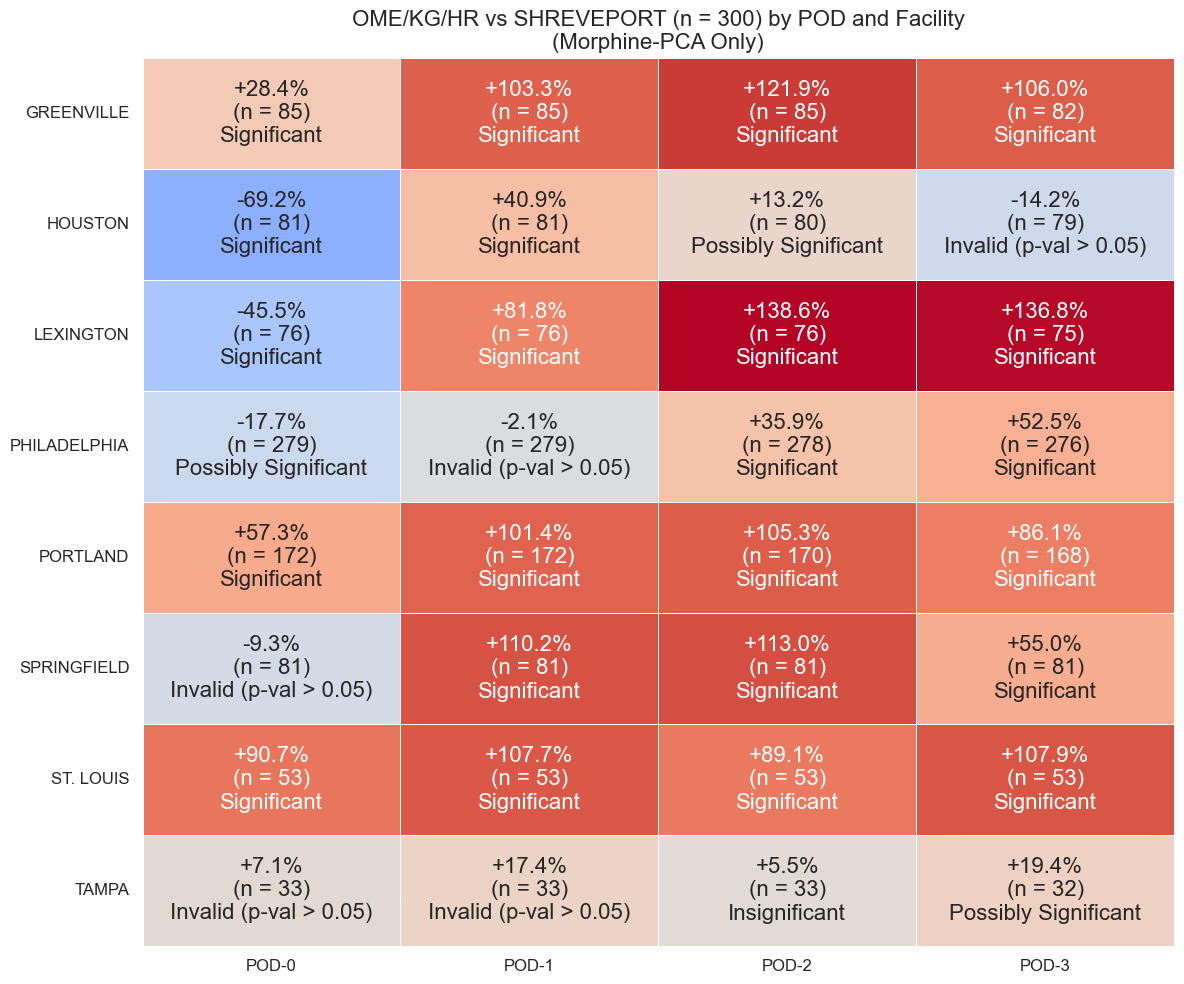

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data
data = [
    ["POD-0", "LEXINGTON", 76, 0.0000, -45.55],
    ["POD-0", "PORTLAND", 172, 0.0000, 57.33],
    ["POD-0", "GREENVILLE", 85, 0.0000, 28.37],
    ["POD-0", "ST. LOUIS", 53, 0.0000, 90.70],
    ["POD-0", "SPRINGFIELD", 81, 0.5724, -9.32],
    ["POD-0", "TAMPA", 33, 0.3772, 7.09],
    ["POD-0", "HOUSTON", 81, 0.0000, -69.17],
    ["POD-0", "PHILADELPHIA", 279, 0.0000, -17.71],
    ["POD-1", "LEXINGTON", 76, 0.0000, 81.81],
    ["POD-1", "PORTLAND", 172, 0.0000, 101.41],
    ["POD-1", "GREENVILLE", 85, 0.0000, 103.33],
    ["POD-1", "ST. LOUIS", 53, 0.0000, 107.67],
    ["POD-1", "SPRINGFIELD", 81, 0.0000, 110.24],
    ["POD-1", "TAMPA", 33, 0.0723, 17.40],
    ["POD-1", "HOUSTON", 81, 0.0000, 40.85],
    ["POD-1", "PHILADELPHIA", 279, 0.1022, -2.07],
    ["POD-2", "LEXINGTON", 76, 0.0000, 138.57],
    ["POD-2", "PORTLAND", 170, 0.0000, 105.30],
    ["POD-2", "GREENVILLE", 85, 0.0000, 121.90],
    ["POD-2", "ST. LOUIS", 53, 0.0000, 89.10],
    ["POD-2", "SPRINGFIELD", 81, 0.0000, 113.02],
    ["POD-2", "TAMPA", 33, 0.0317, 5.49],
    ["POD-2", "HOUSTON", 80, 0.0433, 13.15],
    ["POD-2", "PHILADELPHIA", 278, 0.0000, 35.91],
    ["POD-3", "LEXINGTON", 75, 0.0000, 136.82],
    ["POD-3", "PORTLAND", 168, 0.0000, 86.09],
    ["POD-3", "GREENVILLE", 82, 0.0000, 105.99],
    ["POD-3", "ST. LOUIS", 53, 0.0000, 107.87],
    ["POD-3", "SPRINGFIELD", 81, 0.0000, 54.96],
    ["POD-3", "TAMPA", 32, 0.0161, 19.36],
    ["POD-3", "HOUSTON", 79, 0.1414, -14.19],
    ["POD-3", "PHILADELPHIA", 276, 0.0000, 52.49],
]

df = pd.DataFrame(data, columns=["POD", "Facility", "N", "p_value", "pct_diff"])

# Interpretation logic
def interpret(row):
    if row["N"] < 3:
        return "Invalid"
    elif row["p_value"] >= 0.05:
        return "Invalid (p-val > 0.05)"
    elif abs(row["pct_diff"]) >= 20:
        return "Significant"
    elif abs(row["pct_diff"]) >= 10:
        return "Possibly Significant"
    else:
        return "Insignificant"

df["Interpretation"] = df.apply(interpret, axis=1)

# Annotated label
df["Label"] = df["pct_diff"].map("{:+.1f}%".format) + "\n(n = " + df["N"].astype(str) + ")\n" + df["Interpretation"]

# Pivot for heatmap
pivot = df.pivot(index="Facility", columns="POD", values="pct_diff")
labels = df.pivot(index="Facility", columns="POD", values="Label")

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(pivot, annot=labels, fmt="", cmap="coolwarm", center=0, linewidths=0.5, cbar=False, annot_kws={"fontsize": 16})
plt.title("OME/KG/HR vs SHREVEPORT (n = 300) by POD and Facility\n(Morphine-PCA Only)", fontsize = 16)
plt.xlabel("")
plt.ylabel("")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()


In [52]:
melted_df['TYPE'].value_counts()

TYPE
1-Morphine-PCA         4591
2-Hydromorphone-PCA    3410
3-Epi (w/Opioid)       1052
4-Block w/Opioid        359
Name: count, dtype: int64

In [100]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for shap from https://files.pythonhosted.org/packages/17/48/bbcd638a391ac0fb30033398a3cca60ba5c36941d962dd74958e67069108/shap-0.49.1-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for slicer==0.0.8 from https://files.pythonhosted.org/packages/63/81/9ef641ff4e12cbcca30e54e72fb0951a2ba195d0cda0ba4100e532d929db/slicer-0.0.8-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/546.8 kB ? eta -:--:--
   ---- ----------------------------------- 61.4/546.8 kB 1.6 MB/s eta 0:00:01
   -------------------------- ------------- 358.4/546.8 kB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 546.8/546.8 kB 4.9 MB/s eta 0:00:00


In [103]:
import shap
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

# Define features and target
X = melted_df[['FAC']]
y = melted_df['OME/KG/HR']

# Encode categorical variables
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), ['FAC'])
])

# Fit model
model = make_pipeline(preprocessor, RandomForestRegressor(n_estimators=100, random_state=42))
model.fit(X, y)

# Extract model and transformed data for SHAP
rf = model.named_steps['randomforestregressor']
X_transformed = model.named_steps['columntransformer'].transform(X)

# Compute SHAP values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_transformed)

# Plot summary
shap.summary_plot(shap_values, X_transformed, feature_names=model.named_steps['columntransformer'].get_feature_names_out())


UFuncTypeError: Cannot cast ufunc 'isnan' input from dtype('O') to dtype('bool') with casting rule 'same_kind'

In [104]:
X = melted_df[['FAC', 'TYPE']].dropna()
y = melted_df.loc[X.index, 'OME/KG/HR'].dropna()


In [105]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)  # force dense output


In [106]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

preprocessor = ColumnTransformer([
    ('cat', encoder, ['FAC', 'TYPE'])
])

model = make_pipeline(preprocessor, RandomForestRegressor(n_estimators=100, random_state=42))
model.fit(X, y)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['FAC', 'TYPE'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

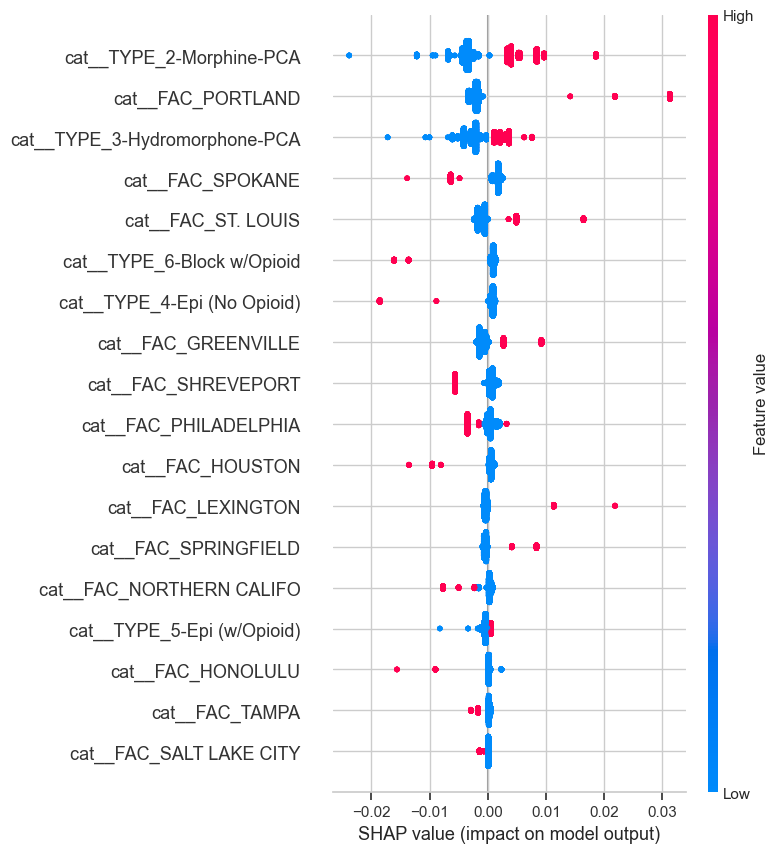

In [107]:
rf = model.named_steps['randomforestregressor']
X_transformed = model.named_steps['columntransformer'].transform(X)

import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_transformed)

shap.summary_plot(shap_values, X_transformed, feature_names=preprocessor.get_feature_names_out())


In [108]:
pods = ['POD-0', 'POD-1', 'POD-2', 'POD-3']
pod_dfs = {pod: melted_df[melted_df['POD'] == pod].dropna(subset=['OME/KG/HR', 'FAC', 'TYPE']) for pod in pods}



🔍 SHAP Summary for POD-0


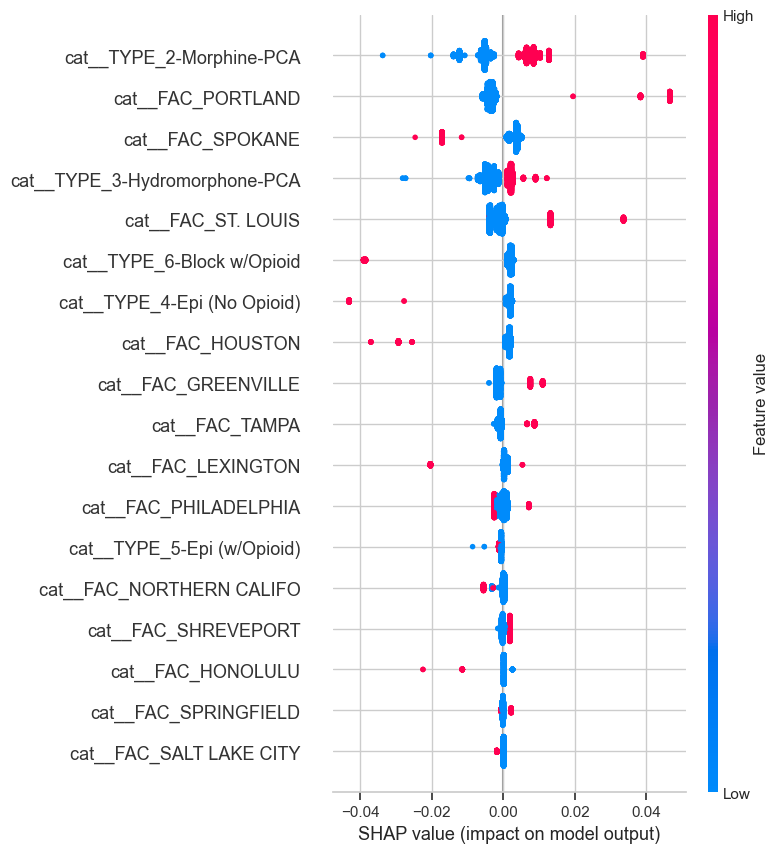


🔍 SHAP Summary for POD-1


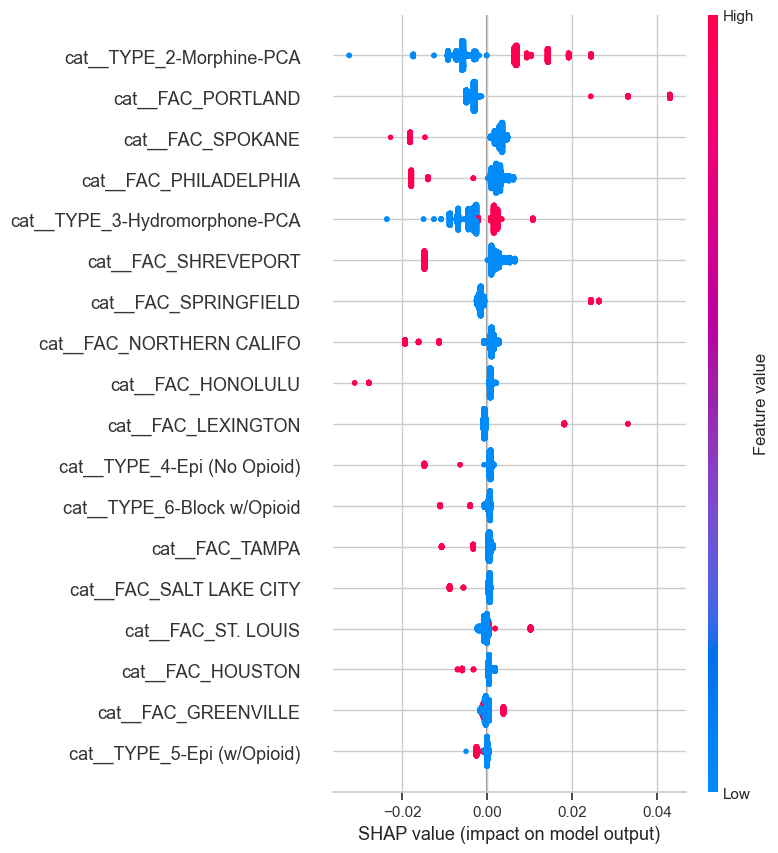


🔍 SHAP Summary for POD-2


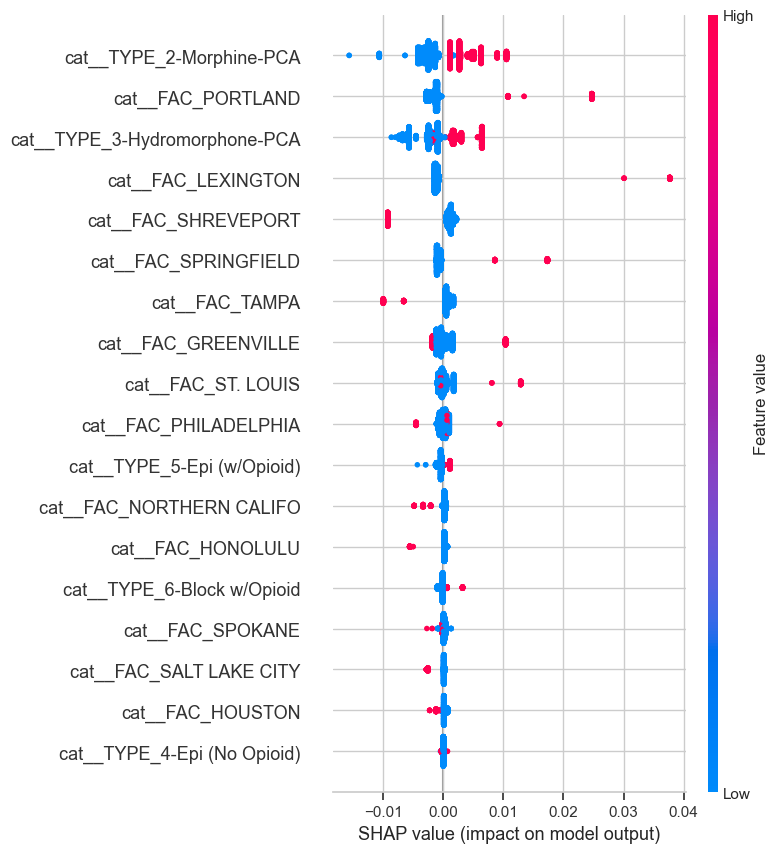


🔍 SHAP Summary for POD-3


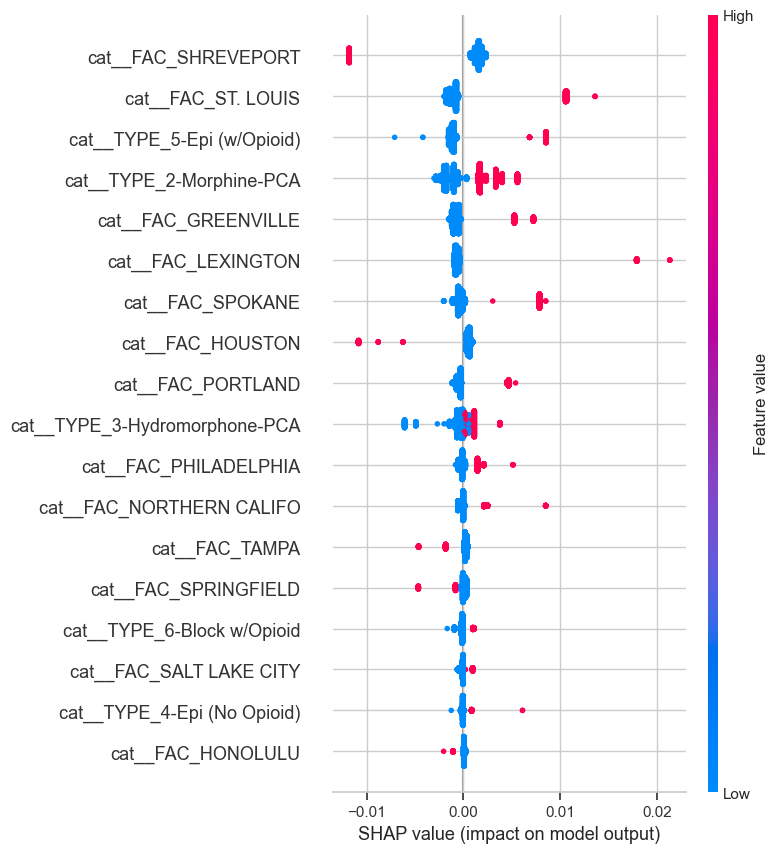

In [109]:
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

for pod, df in pod_dfs.items():
    X = df[['FAC', 'TYPE', 'YEAR']]
    y = df['OME/KG/HR']

    encoder = OneHotEncoder(drop='first', sparse_output=False)
    preprocessor = ColumnTransformer([('cat', encoder, ['FAC', 'TYPE'])])
    model = make_pipeline(preprocessor, RandomForestRegressor(n_estimators=100, random_state=42))
    model.fit(X, y)

    rf = model.named_steps['randomforestregressor']
    X_transformed = model.named_steps['columntransformer'].transform(X)

    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_transformed)

    print(f"\n🔍 SHAP Summary for {pod}")
    shap.summary_plot(shap_values, X_transformed, feature_names=preprocessor.get_feature_names_out())


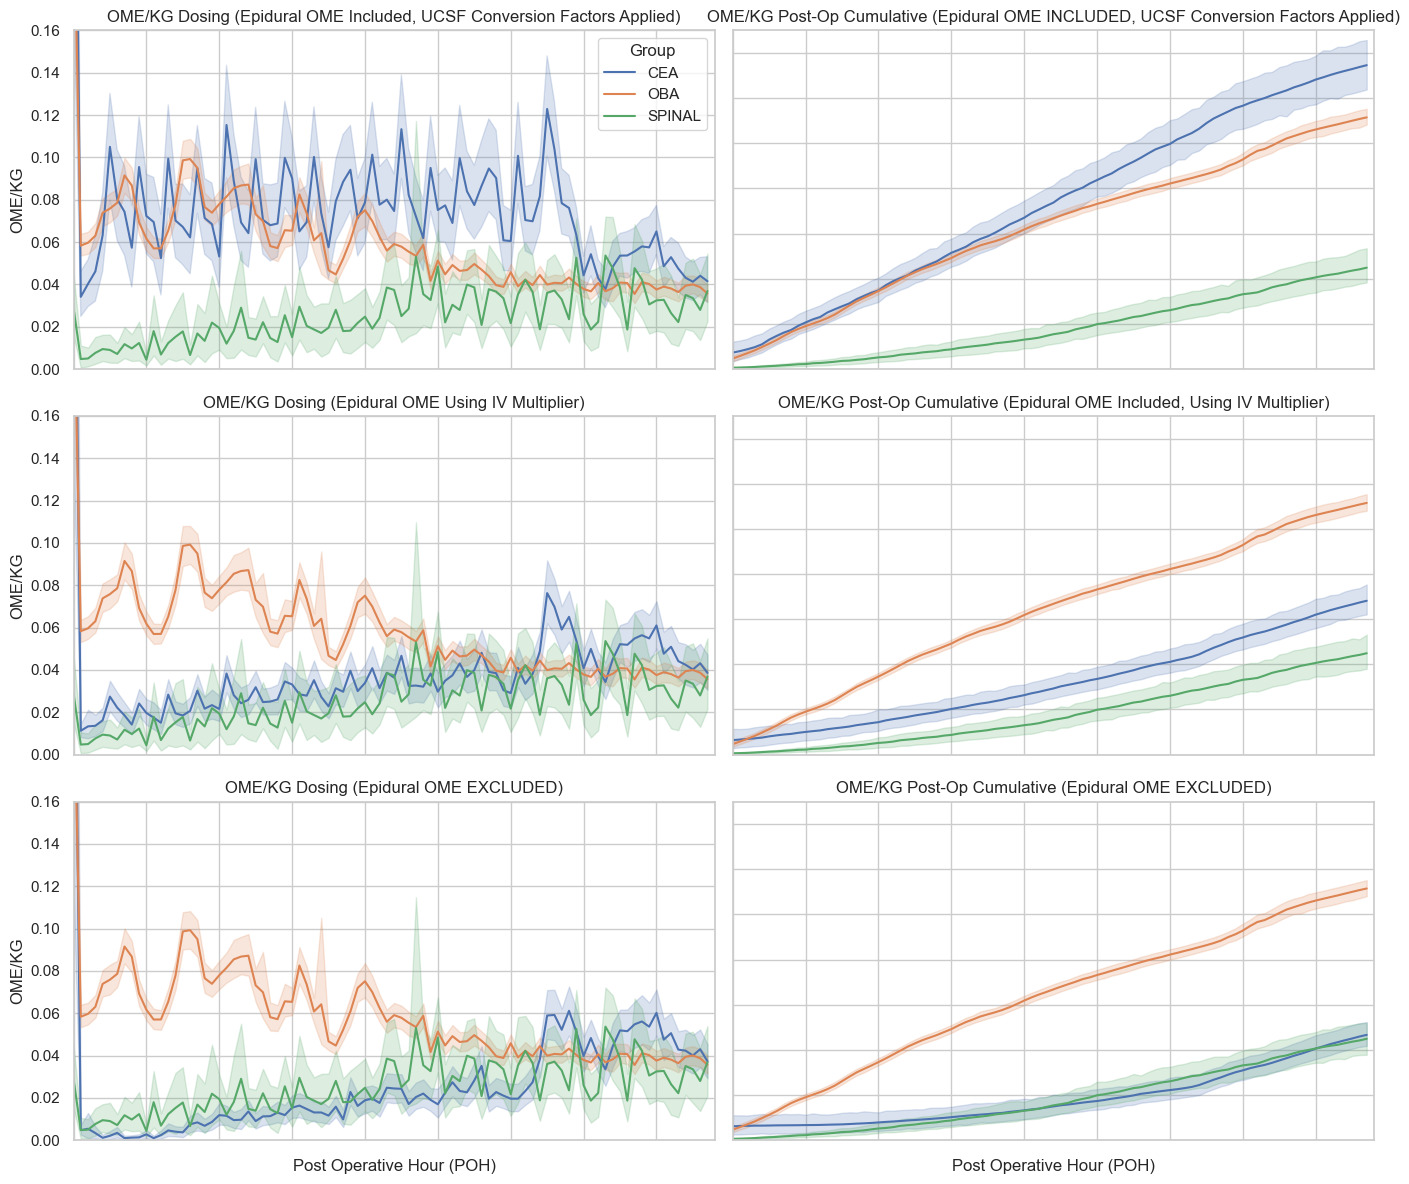

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12), sharex=True, sharey=False)

# Data sources
datasets = [
    [clean3, clean4],
    [clean8, clean9],
    [clean5, clean6]
]

titles = [
    ['OME/KG Dosing (Epidural OME Included, UCSF Conversion Factors Applied)',
     'OME/KG Post-Op Cumulative (Epidural OME INCLUDED, UCSF Conversion Factors Applied)'],
    ['OME/KG Dosing (Epidural OME Using IV Multiplier)',
     'OME/KG Post-Op Cumulative (Epidural OME Included, Using IV Multiplier)'],
    ['OME/KG Dosing (Epidural OME EXCLUDED)',
     'OME/KG Post-Op Cumulative (Epidural OME EXCLUDED)']
]

# Plotting loop
for row in range(3):
    for col in range(2):
        ax = axes[row, col]
        data = datasets[row][col]
        sns.lineplot(data=data, x='POH', y='OME/KG', hue='GROUP', ax=ax)
        ax.set_xlim(0, 88)
        ax.set_title(titles[row][col], fontsize=12)

        # Y-labels only on column 1
        if col == 0:
            ax.set_ylabel('OME/KG')
        else:
            ax.set_ylabel('')
            ax.set_yticklabels([])

        # X-labels only on row 3
        if row == 2:
            ax.set_xlabel('Post Operative Hour (POH)')
        else:
            ax.set_xlabel('')
            ax.set_xticklabels([])

        # Y-axis range
        if col == 0:
            ax.set_ylim(0, 0.16)
        else:
            ax.set_ylim(0, 7.5)

        # Legend only in top-left
        if row == 0 and col == 0:
            ax.legend(title='Group')
        else:
            ax.get_legend().remove()

plt.tight_layout()
plt.show()


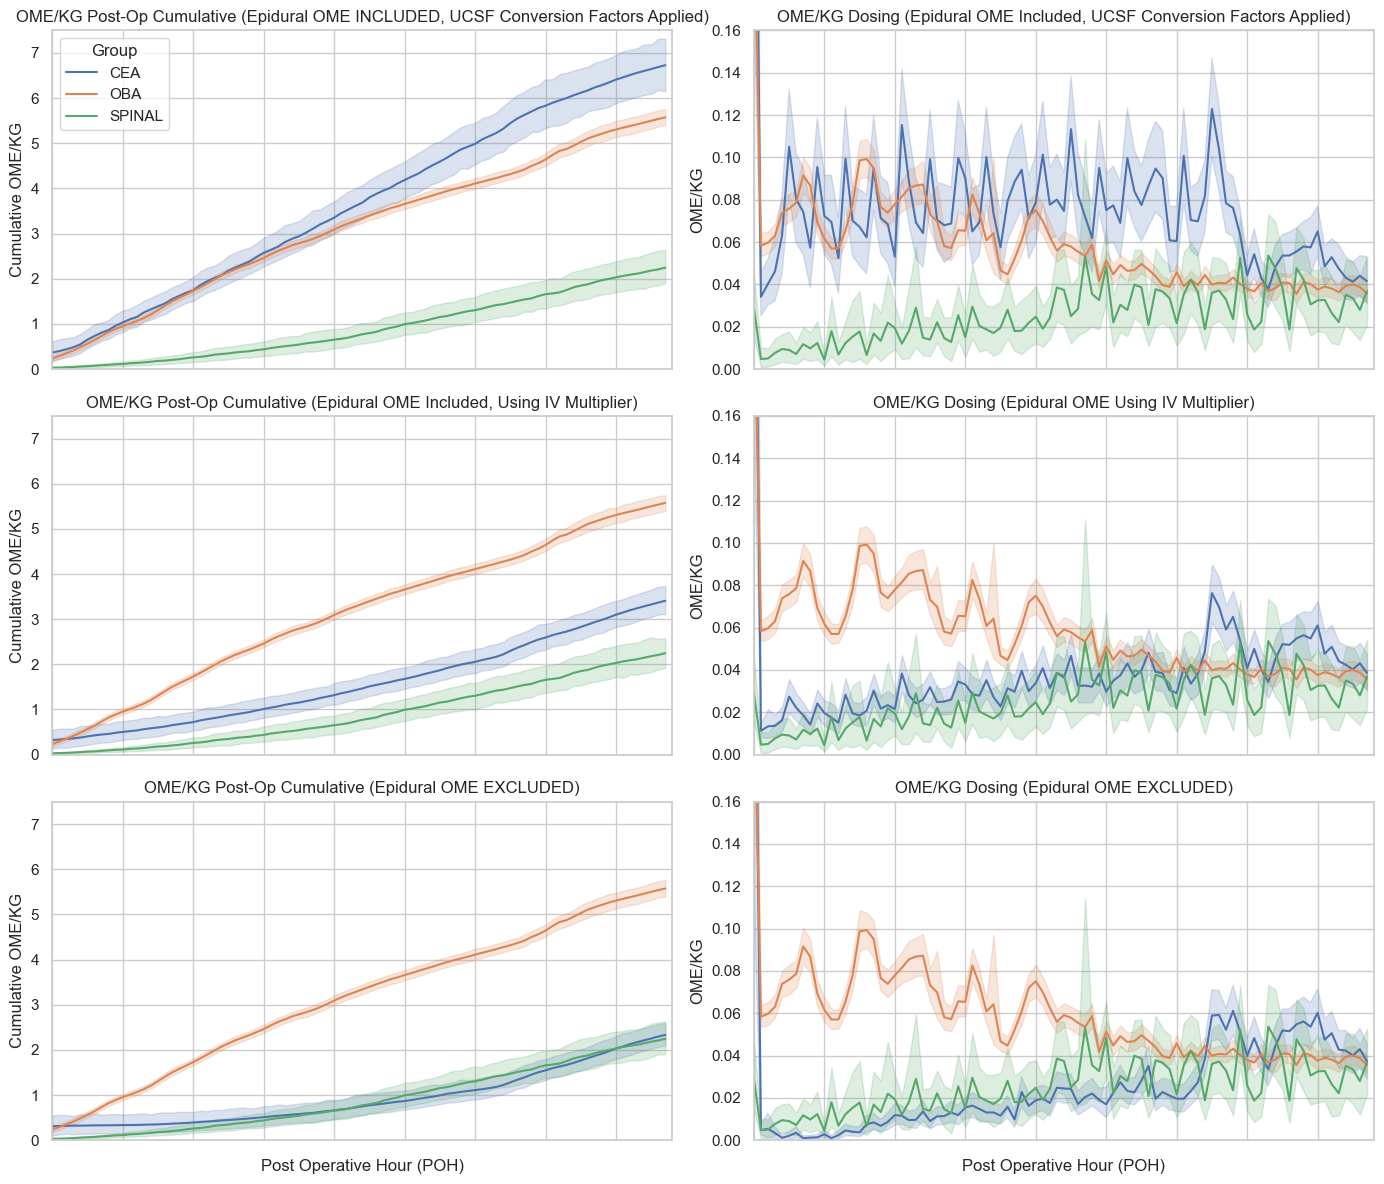

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up 2x3 grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12), sharex=True)

# Data sources and titles
cumulative_data = [clean4, clean9, clean6]
dosing_data = [clean3, clean8, clean5]

cumulative_titles = [
    'OME/KG Post-Op Cumulative (Epidural OME INCLUDED, UCSF Conversion Factors Applied)',
    'OME/KG Post-Op Cumulative (Epidural OME Included, Using IV Multiplier)',
    'OME/KG Post-Op Cumulative (Epidural OME EXCLUDED)'
]

dosing_titles = [
    'OME/KG Dosing (Epidural OME Included, UCSF Conversion Factors Applied)',
    'OME/KG Dosing (Epidural OME Using IV Multiplier)',
    'OME/KG Dosing (Epidural OME EXCLUDED)'
]

# Plotting loop
for row in range(3):
    # Column 1: cumulative
    ax_cum = axes[row, 0]
    sns.lineplot(data=cumulative_data[row], x='POH', y='OME/KG', hue='GROUP', ax=ax_cum)
    ax_cum.set_xlim(0, 88)
    ax_cum.set_ylim(0, 7.5)
    ax_cum.set_title(cumulative_titles[row], fontsize=12)
    ax_cum.set_ylabel('Cumulative OME/KG')
    if row == 2:
        ax_cum.set_xlabel('Post Operative Hour (POH)')
    else:
        ax_cum.set_xlabel('')
        ax_cum.set_xticklabels([])

    # Column 2: dosing
    ax_dose = axes[row, 1]
    sns.lineplot(data=dosing_data[row], x='POH', y='OME/KG', hue='GROUP', ax=ax_dose)
    ax_dose.set_xlim(0, 88)
    ax_dose.set_ylim(0, 0.16)
    ax_dose.set_title(dosing_titles[row], fontsize=12)
    ax_dose.set_ylabel('OME/KG')
    if row == 2:
        ax_dose.set_xlabel('Post Operative Hour (POH)')
    else:
        ax_dose.set_xlabel('')
        ax_dose.set_xticklabels([])

    # Legend only in top-left
    if row == 0:
        ax_cum.legend(title='Group', loc='upper left')
        ax_dose.get_legend().remove()
    else:
        ax_cum.get_legend().remove()
        ax_dose.get_legend().remove()

plt.tight_layout()
plt.show()


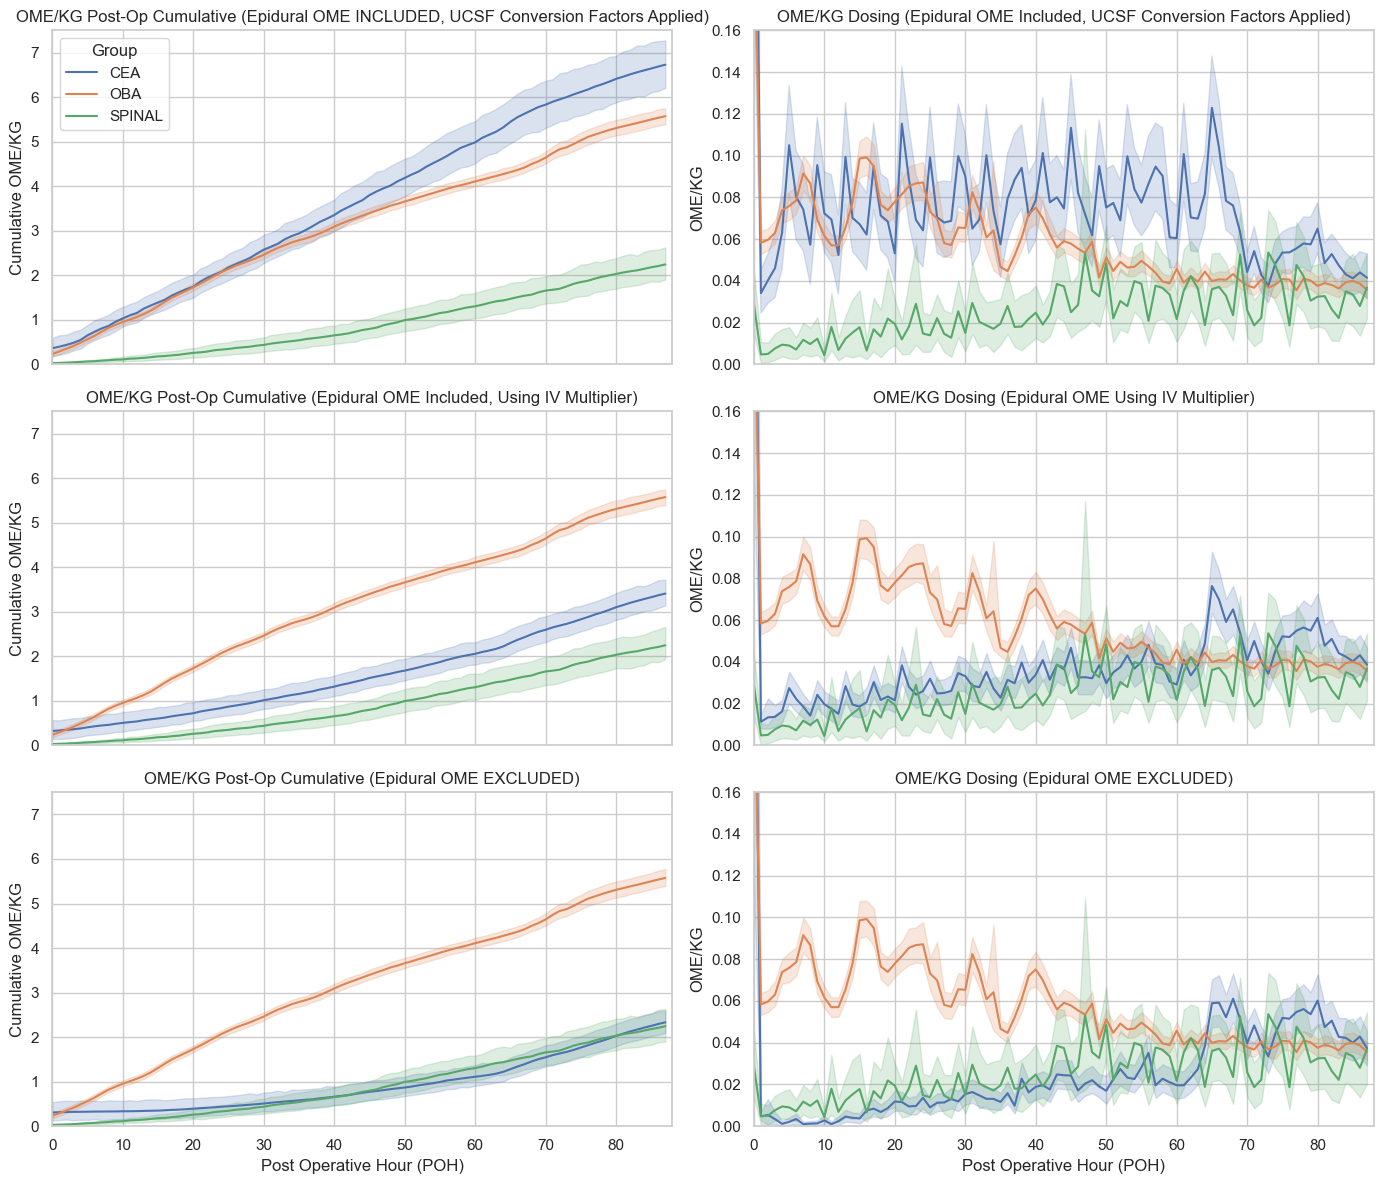

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up 2x3 grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12), sharex=True)

# Data sources and titles
cumulative_data = [clean4, clean9, clean6]
dosing_data = [clean3, clean8, clean5]

cumulative_titles = [
    'OME/KG Post-Op Cumulative (Epidural OME INCLUDED, UCSF Conversion Factors Applied)',
    'OME/KG Post-Op Cumulative (Epidural OME Included, Using IV Multiplier)',
    'OME/KG Post-Op Cumulative (Epidural OME EXCLUDED)'
]

dosing_titles = [
    'OME/KG Dosing (Epidural OME Included, UCSF Conversion Factors Applied)',
    'OME/KG Dosing (Epidural OME Using IV Multiplier)',
    'OME/KG Dosing (Epidural OME EXCLUDED)'
]

# Plotting loop
for row in range(3):
    # Column 1: cumulative
    ax_cum = axes[row, 0]
    sns.lineplot(data=cumulative_data[row], x='POH', y='OME/KG', hue='GROUP', ax=ax_cum)
    ax_cum.set_xlim(0, 88)
    ax_cum.set_ylim(0, 7.5)
    ax_cum.set_title(cumulative_titles[row], fontsize=12)
    ax_cum.set_ylabel('Cumulative OME/KG')
    if row == 2:
        ax_cum.set_xlabel('Post Operative Hour (POH)')
    else:
        ax_cum.set_xlabel('')

    # Column 2: dosing
    ax_dose = axes[row, 1]
    sns.lineplot(data=dosing_data[row], x='POH', y='OME/KG', hue='GROUP', ax=ax_dose)
    ax_dose.set_xlim(0, 88)
    ax_dose.set_ylim(0, 0.16)
    ax_dose.set_title(dosing_titles[row], fontsize=12)
    ax_dose.set_ylabel('OME/KG')
    if row == 2:
        ax_dose.set_xlabel('Post Operative Hour (POH)')
    else:
        ax_dose.set_xlabel('')

    # Legend only in top-left
    if row == 0:
        ax_cum.legend(title='Group', loc='upper left')
        ax_dose.get_legend().remove()
    else:
        ax_cum.get_legend().remove()
        ax_dose.get_legend().remove()

plt.tight_layout()
plt.show()


In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

#This is the figure showing cumulative hourly totals with Epidural opioids ADDED to the total

# Set figure size
plt.figure(figsize=(12,8))  # width x height in inches

# Create the lineplot with hue by GROUP
sns.lineplot(data=clean9, x='POH', y='OME/KG', hue='TYPE')

# Customize axes and labels
plt.title('OME/KG Post-Op Cumulative (Epidural OME Included, Using IV Multiplier) by TYPE')
plt.xlabel('Post Operative Hour (POH)')
plt.ylabel('Cumulative OME/KG')
#plt.ylim(0, 7.5)
plt.xlim(0, 88)# cap y-axis to focus on action range
plt.legend(title='Group')
plt.tight_layout()
plt.show()


NameError: name 'clean9' is not defined

<Figure size 1200x800 with 0 Axes>

*conda 9 = cumulative opioid totals with epidural opioids included with IV multiplier  
*conda 8 = hourly average opioid totals with epidural opioids included with IV multiplier  
*conda 6 = cumulative opioid totals with epidural opioids removed  
*conda 5 = hourly average opioid dosing with epidural opioids removed  
*conda 4 = cumulative opioid totals with epidural opioids included  
*conda 3 = hourly average opioid dosing with epidural opioids included  
*conda 2 = includes OBA 2 table from which matrices are derived  
*conda 1 = same as conda 2  





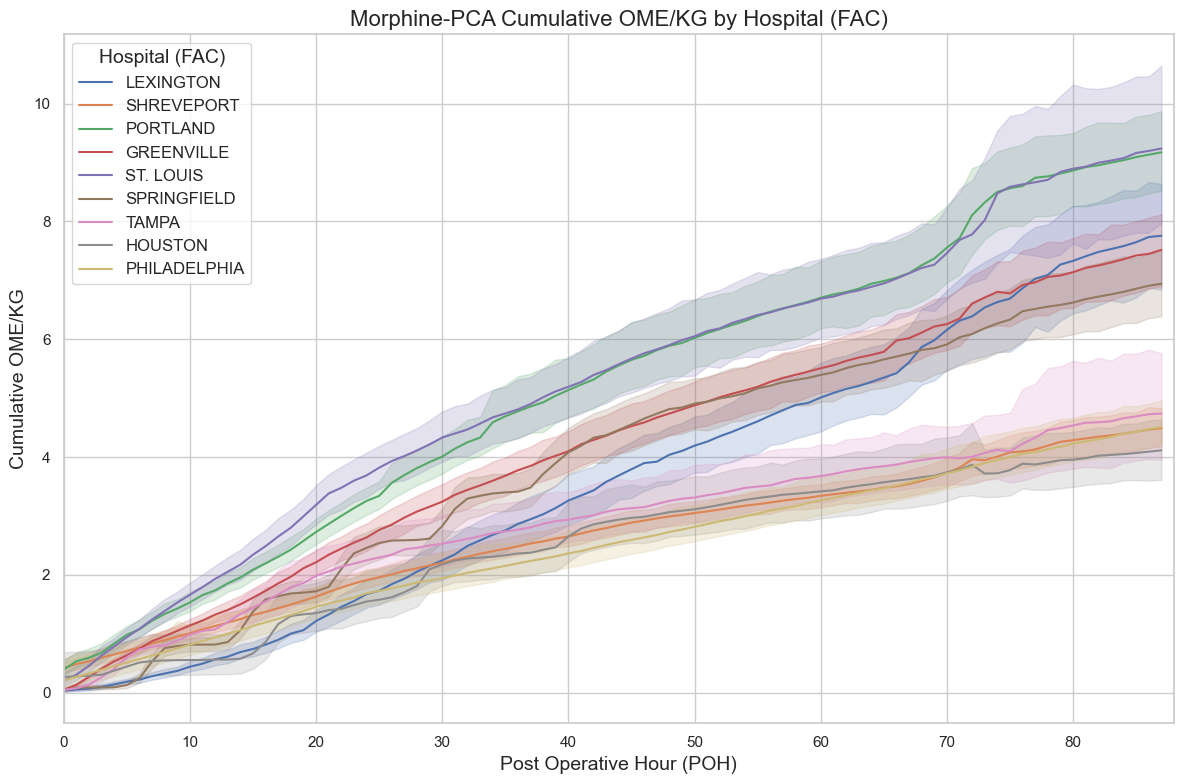

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Subset to Morphine-PCA only
subset = clean9[clean9['TYPE'] == '2-Morphine-PCA']

# Create the lineplot with hue by FAC
plt.figure(figsize=(12, 8))
sns.lineplot(data=subset, x='POH', y='OME/KG', hue='FAC')

# Customize axes and labels
plt.title('Morphine-PCA Cumulative OME/KG by Hospital (FAC)', fontsize=16)
plt.xlabel('Post Operative Hour (POH)', fontsize=14)
plt.ylabel('Cumulative OME/KG', fontsize=14)
plt.xlim(0, 88)
plt.legend(title='Hospital (FAC)', fontsize=12, title_fontsize=14)
plt.tight_layout()
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


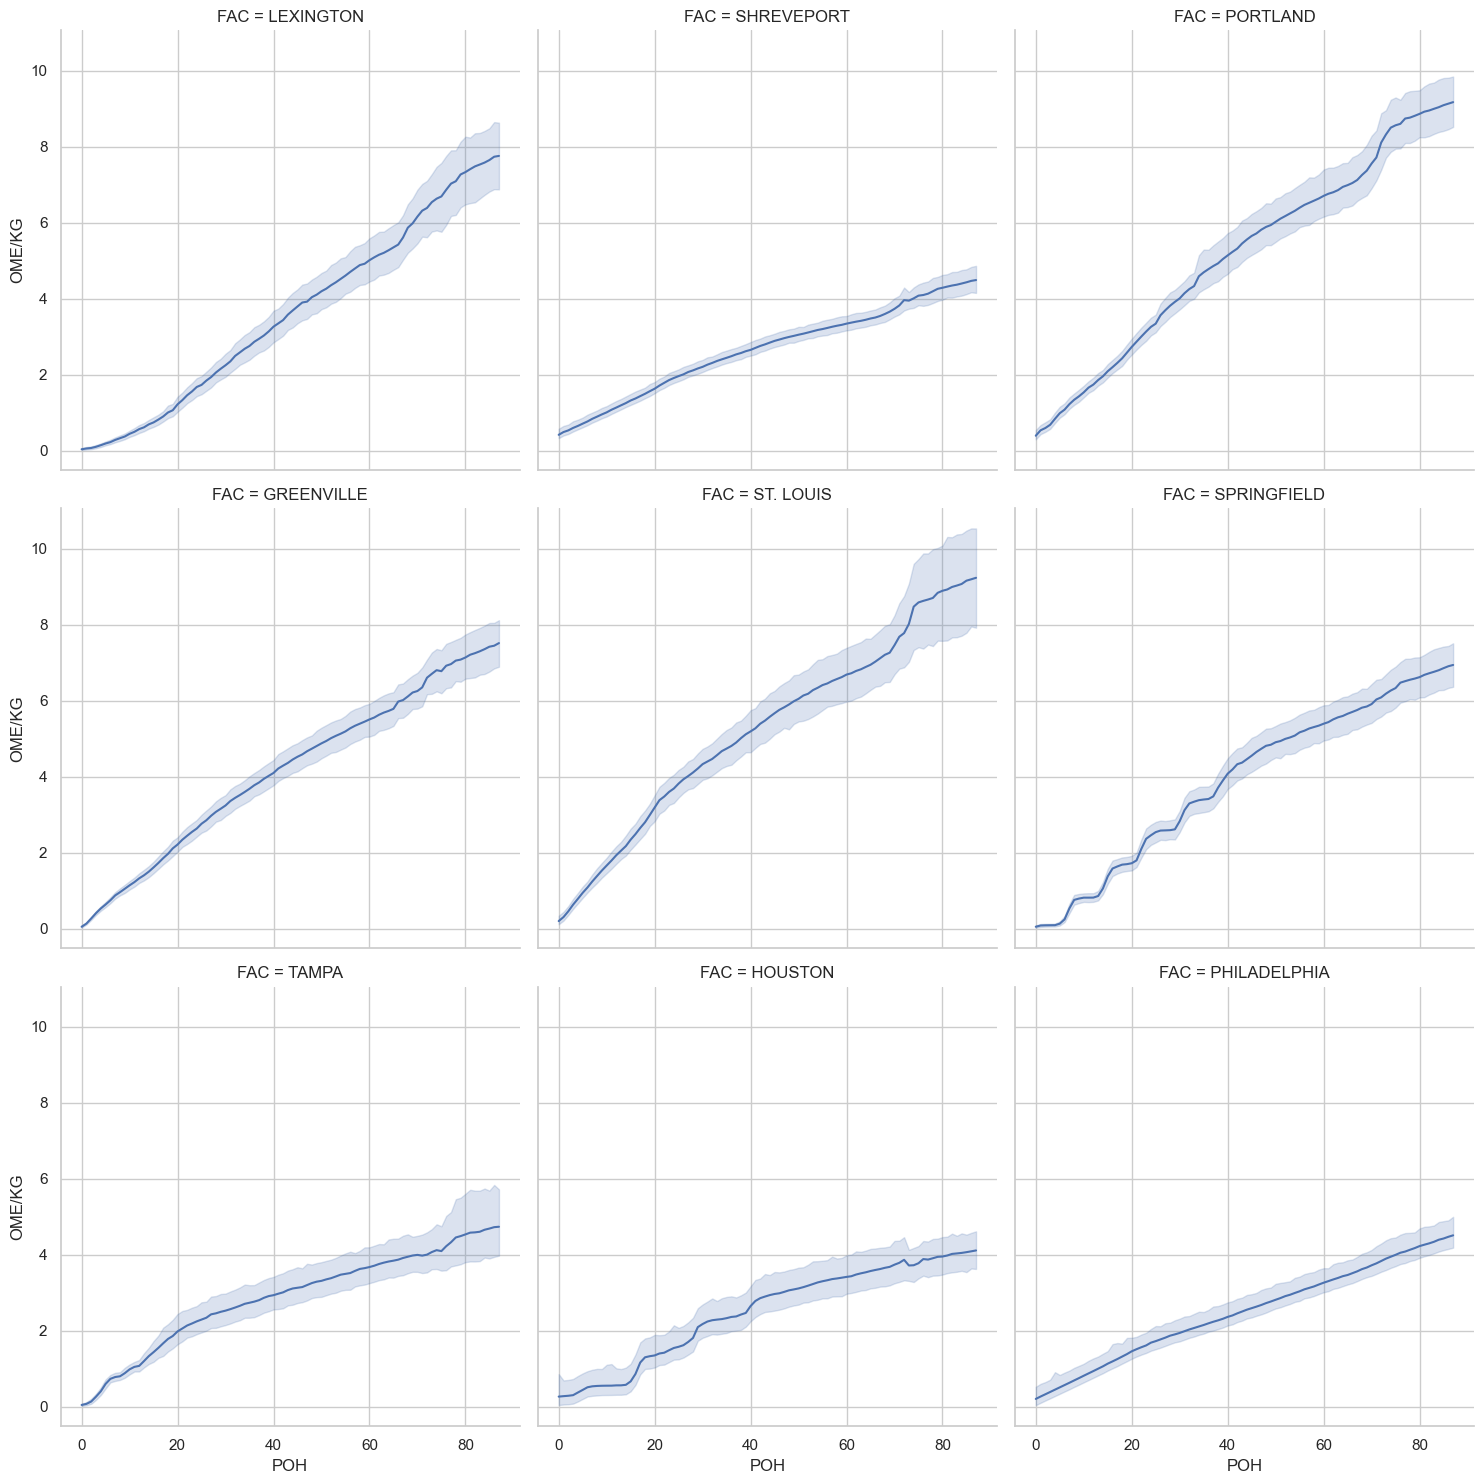

In [20]:
sns.relplot(data=subset, x='POH', y='OME/KG', col='FAC', kind='line', col_wrap=3)


In [21]:
max_ome = clean9.groupby(['EID', 'TYPE'])['OME/KG'].max().reset_index()


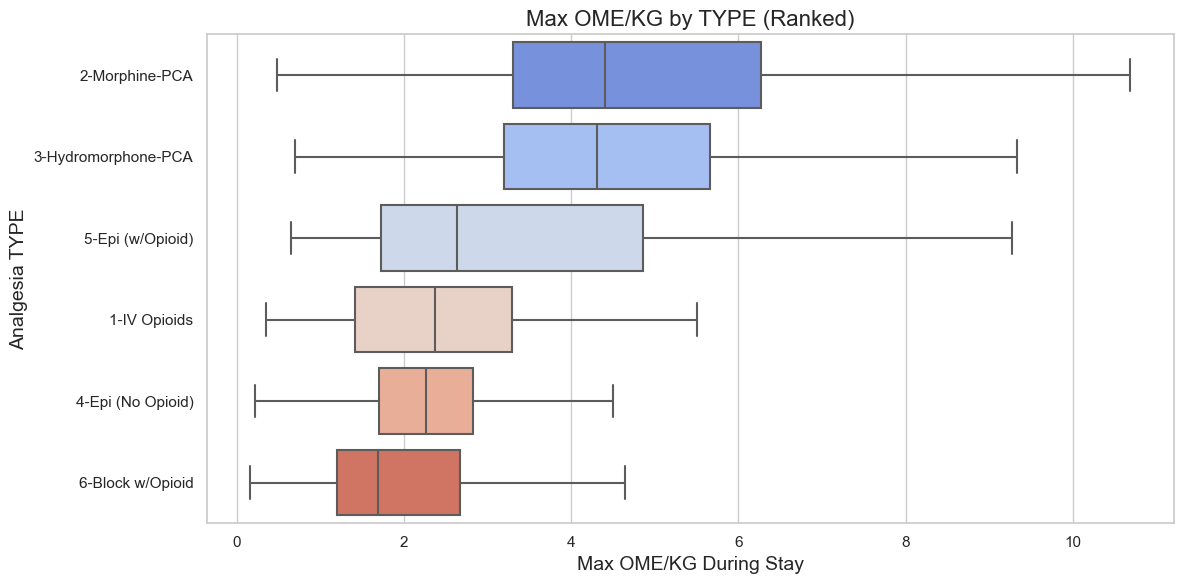

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: rank TYPEs by median max OME/KG
type_order = max_ome.groupby('TYPE')['OME/KG'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=max_ome,
    x='OME/KG',
    y='TYPE',
    order=type_order,
    orient='h',
    showfliers=False,
    palette='coolwarm'
)

plt.title('Max OME/KG by TYPE (Ranked)', fontsize=16)
plt.xlabel('Max OME/KG During Stay', fontsize=14)
plt.ylabel('Analgesia TYPE', fontsize=14)
plt.tight_layout()
plt.show()


In [24]:
max_ome.describe()

,EID,OME/KG
count,2.573000e+03,2573.000000
mean,2.375862e+07,4.601689
std,3.680520e+06,3.046809
min,1.584183e+07,0.165929
25%,2.105233e+07,2.738351
50%,2.397172e+07,3.976676
75%,2.679414e+07,5.639097
max,3.018406e+07,48.465838


In [25]:
# Step 1: Find the row where each patient hit their max OME/KG
max_rows = clean9.loc[clean9.groupby('EID')['OME/KG'].idxmax()].copy()

# Step 2: Compute OME/KG per hour
max_rows['OME/KG/HR'] = max_rows['OME/KG'] / max_rows['POH']


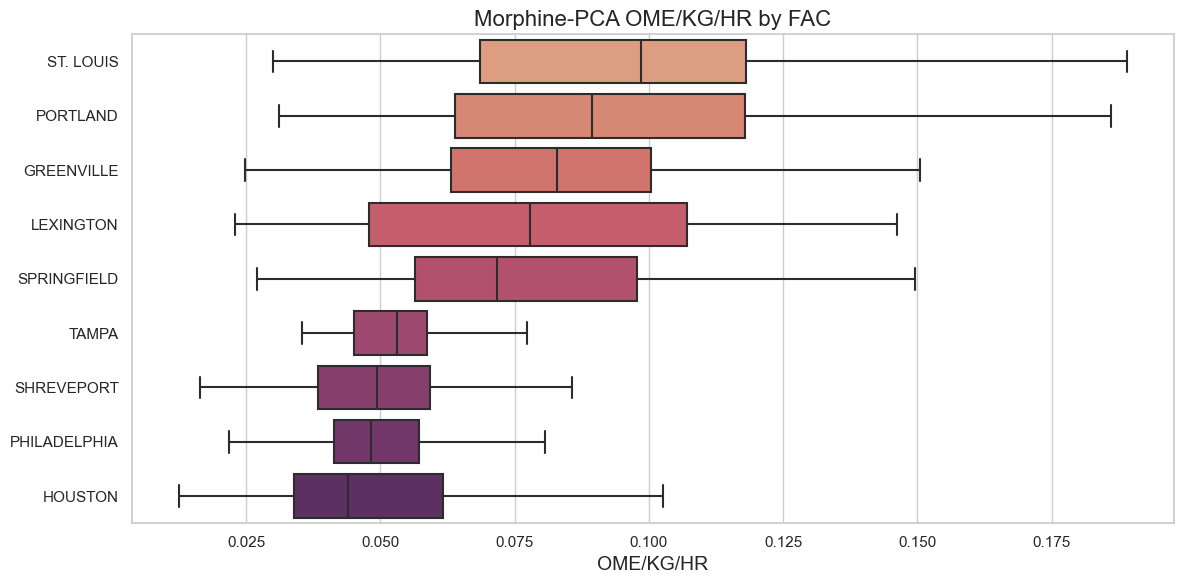

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

subset = max_rows[max_rows['TYPE'] == '2-Morphine-PCA']

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=subset,
    x='OME/KG/HR',
    y='FAC',  # or 'FAC'
    order=subset.groupby('FAC')['OME/KG/HR'].median().sort_values(ascending=False).index,
    orient='h',
    showfliers=False,
    palette='flare'
)

plt.title('Morphine-PCA OME/KG/HR by FAC', fontsize=16)
plt.xlabel('OME/KG/HR', fontsize=14)
plt.ylabel('', fontsize=14)
plt.tight_layout()
plt.show()


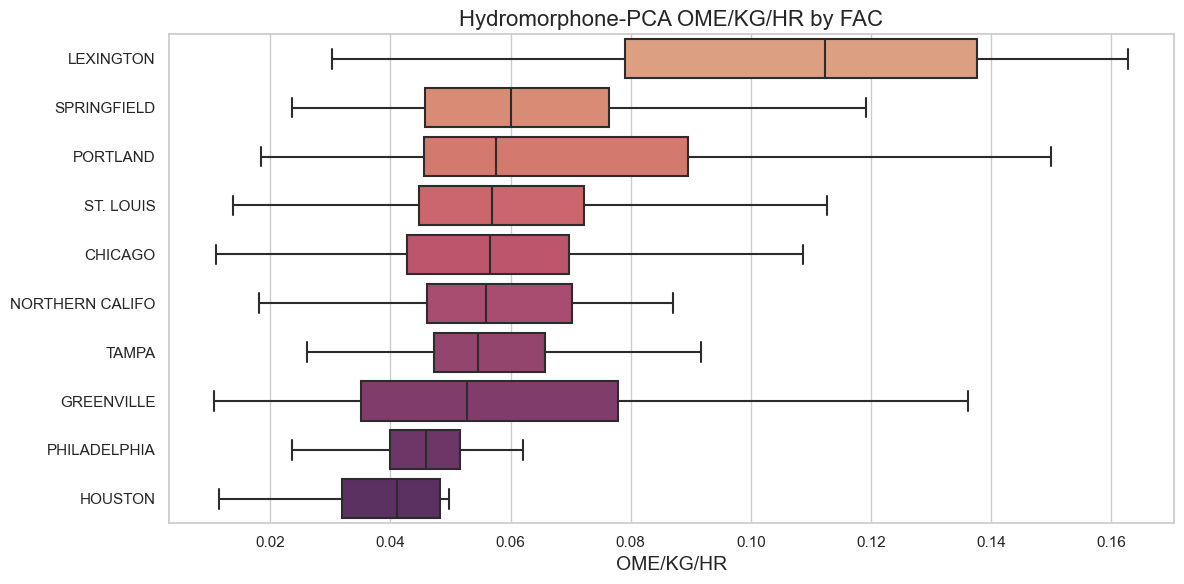

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

subset = max_rows[max_rows['TYPE'] == '3-Hydromorphone-PCA']

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=subset,
    x='OME/KG/HR',
    y='FAC',  # or 'FAC'
    order=subset.groupby('FAC')['OME/KG/HR'].median().sort_values(ascending=False).index,
    orient='h',
    showfliers=False,
    palette='flare'
)

plt.title('Hydromorphone-PCA OME/KG/HR by FAC', fontsize=16)
plt.xlabel('OME/KG/HR', fontsize=14)
plt.ylabel('', fontsize=14)
plt.tight_layout()
plt.show()
